In [558]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Step 1: Data Processing

In [559]:
df = pd.read_parquet('hk_stock_data_final.parquet')
df_status = pd.read_csv('hk_stock_listing&delisted.csv')

In [560]:
df

,Instrument,Price Close,Date,Company Market Cap (Millions),Company Shares (Millions),Price To Book Value Per Share (Daily Time Series Ratio),Current Ratio,Basic EPS Excluding Extraordinary Items,"Gross Margin, Percent",Total Debt (Millions),...,diff_DFY,HML,Mkt - RF_lagged,SMB_lagged,diff_TBL_3MHIBOR_lagged,BM_HSI_lagged,diff_RF_Monthly_lagged,DP_HSI_lagged,MOM_lagged,Target_Forward_Log_Return
0,0001.HK,53.632673,2000-01-31,225734.975250,2297.55700,2.641782,1.60082,2.66021,0.713949,15059.000,...,0.0004,-0.144858,-0.081736,0.052933,-0.005267,0.308269,-0.000370,0.027987,0.153355,0.052056
1,0001.HK,56.498541,2000-02-29,237797.149500,2297.55700,2.782946,1.60082,2.66021,0.713949,15059.000,...,0.0006,0.034890,0.052064,-0.030179,0.001406,0.318321,0.000188,0.030164,-0.122069,0.118320
2,0001.HK,63.594976,2000-03-31,267665.390500,2297.55700,1.888385,1.46801,25.84176,0.738313,17666.000,...,0.0009,0.088196,0.025343,-0.015227,0.001116,0.326448,0.000108,0.030922,0.038411,-0.225292
3,0001.HK,50.766805,2000-04-30,213672.801000,2297.55700,1.507466,1.46801,25.84176,0.738313,17666.000,...,0.0011,-0.035742,-0.097587,0.060353,-0.000178,0.325462,-0.000086,0.032055,0.127028,-0.266405
4,0001.HK,38.893923,2000-05-31,163700.936250,2297.55700,1.154914,1.46801,25.84176,0.738313,17666.000,...,0.0009,0.024745,-0.115767,0.001877,0.005290,0.379409,0.000601,0.035047,0.024611,0.191055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641355,9999.HK,204.400000,2025-07-31,647645.279060,3165.99142,4.129427,3.08701,9.27919,0.624977,12233.048,...,-0.0002,-0.035303,0.047360,0.058249,0.003567,1.131171,0.000117,0.037875,0.012705,0.038392
641356,9999.HK,212.400000,2025-08-31,672376.433701,3165.99142,4.113634,3.08701,9.27919,0.624977,12233.048,...,-0.0002,0.017637,0.018052,0.053902,-0.000621,1.094200,0.000255,0.036323,0.026110,0.108745
641357,9999.HK,236.800000,2025-09-30,749005.547380,3165.99142,4.587279,3.08701,9.27919,0.624977,12233.048,...,0.0000,0.031786,0.010316,0.011791,0.016783,1.072007,0.001886,0.035983,0.021812,-0.087319
641358,9999.HK,217.000000,2025-10-31,689320.572834,3165.99142,4.209127,3.08701,9.27919,0.624977,12233.048,...,-0.0003,0.032190,-0.002129,-0.034972,0.002299,0.979816,0.000201,0.033745,0.012960,-0.013921


## Identifiers & Basic Information

In [561]:
def merge_and_encode_sectors(df, df_status):
    """
    Merges Sector and Industry columns from df_status into df (if not already present), 
    and applies One-Hot Encoding to them for Neural Network input.
    """
    # 1. Clean column names in both dataframes to remove hidden leading/trailing spaces
    df.columns = df.columns.str.strip()
    df_status.columns = df_status.columns.str.strip()
    
    categorical_cols = ['TRBC Business Sector Name', 'TRBC Industry Group Name']
    
    # 2. Check which columns actually need to be merged
    # If they are already in df, we don't need to pull them from df_status
    cols_to_merge = ['Instrument']
    for col in categorical_cols:
        if col not in df.columns:
            cols_to_merge.append(col)
            
    # 3. Merge only if there are missing categorical columns to bring over
    if len(cols_to_merge) > 1:
        df_merged = pd.merge(df, df_status[cols_to_merge], on='Instrument', how='left')
    else:
        # The columns are already in df, no need to merge
        df_merged = df.copy()
    
    # 4. Apply One-Hot Encoding
    # dummy_na=False ignores NaN values. dtype=int converts True/False to 1/0.
    df_encoded = pd.get_dummies(df_merged, columns=categorical_cols, dummy_na=False, dtype=int)
    
    return df_encoded

df = merge_and_encode_sectors(df, df_status)
df.head(5)

,Instrument,Price Close,Date,Company Market Cap (Millions),Company Shares (Millions),Price To Book Value Per Share (Daily Time Series Ratio),Current Ratio,Basic EPS Excluding Extraordinary Items,"Gross Margin, Percent",Total Debt (Millions),...,TRBC Industry Group Name_Renewable Energy,"TRBC Industry Group Name_Schools, Colleges & Universities",TRBC Industry Group Name_Semiconductors & Semiconductor Equipment,TRBC Industry Group Name_Software & IT Services,TRBC Industry Group Name_Specialty Retailers,TRBC Industry Group Name_Telecommunications Services,TRBC Industry Group Name_Textiles & Apparel,TRBC Industry Group Name_Transport Infrastructure,TRBC Industry Group Name_Uranium,TRBC Industry Group Name_Water & Related Utilities
0,0001.HK,53.632673,2000-01-31,225734.97525,2297.557,2.641782,1.60082,2.66021,0.713949,15059.0,...,0,0,0,0,1,0,0,0,0,0
1,0001.HK,56.498541,2000-02-29,237797.14950,2297.557,2.782946,1.60082,2.66021,0.713949,15059.0,...,0,0,0,0,1,0,0,0,0,0
2,0001.HK,63.594976,2000-03-31,267665.39050,2297.557,1.888385,1.46801,25.84176,0.738313,17666.0,...,0,0,0,0,1,0,0,0,0,0
3,0001.HK,50.766805,2000-04-30,213672.80100,2297.557,1.507466,1.46801,25.84176,0.738313,17666.0,...,0,0,0,0,1,0,0,0,0,0
4,0001.HK,38.893923,2000-05-31,163700.93625,2297.557,1.154914,1.46801,25.84176,0.738313,17666.0,...,0,0,0,0,1,0,0,0,0,0


In [562]:
df.to_parquet('hk_stock_NNL_1.parquet')

## Market Data & Size

In [563]:
import pandas as pd
import numpy as np


In [564]:
df = pd.read_parquet('hk_stock_NNL_1.parquet')

In [565]:
df[df['Instrument'] == '0001.HK']

,Instrument,Price Close,Date,Company Market Cap (Millions),Company Shares (Millions),Price To Book Value Per Share (Daily Time Series Ratio),Current Ratio,Basic EPS Excluding Extraordinary Items,"Gross Margin, Percent",Total Debt (Millions),...,TRBC Industry Group Name_Renewable Energy,"TRBC Industry Group Name_Schools, Colleges & Universities",TRBC Industry Group Name_Semiconductors & Semiconductor Equipment,TRBC Industry Group Name_Software & IT Services,TRBC Industry Group Name_Specialty Retailers,TRBC Industry Group Name_Telecommunications Services,TRBC Industry Group Name_Textiles & Apparel,TRBC Industry Group Name_Transport Infrastructure,TRBC Industry Group Name_Uranium,TRBC Industry Group Name_Water & Related Utilities
0,0001.HK,53.632673,2000-01-31,225734.975250,2297.5570,2.641782,1.60082,2.66021,0.713949,15059.0,...,0,0,0,0,1,0,0,0,0,0
1,0001.HK,56.498541,2000-02-29,237797.149500,2297.5570,2.782946,1.60082,2.66021,0.713949,15059.0,...,0,0,0,0,1,0,0,0,0,0
2,0001.HK,63.594976,2000-03-31,267665.390500,2297.5570,1.888385,1.46801,25.84176,0.738313,17666.0,...,0,0,0,0,1,0,0,0,0,0
3,0001.HK,50.766805,2000-04-30,213672.801000,2297.5570,1.507466,1.46801,25.84176,0.738313,17666.0,...,0,0,0,0,1,0,0,0,0,0
4,0001.HK,38.893923,2000-05-31,163700.936250,2297.5570,1.154914,1.46801,25.84176,0.738313,17666.0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,0001.HK,51.400000,2025-07-31,196864.287300,3830.0445,0.368167,1.46729,4.46157,0.514560,324731.0,...,0,0,0,0,1,0,0,0,0,0
307,0001.HK,51.350000,2025-08-31,196672.785075,3830.0445,0.354500,1.46729,4.46157,0.514560,324731.0,...,0,0,0,0,1,0,0,0,0,0
308,0001.HK,51.250000,2025-09-30,196289.780625,3830.0445,0.353809,1.46729,4.46157,0.514560,324731.0,...,0,0,0,0,1,0,0,0,0,0
309,0001.HK,51.500000,2025-10-31,197247.291750,3830.0445,0.355535,1.46729,4.46157,0.514560,324731.0,...,0,0,0,0,1,0,0,0,0,0


In [566]:
def process_market_data(df):
    """
    Processes market data by calculating log returns and log transformations
    for Market Cap and Shares.
    
    Assumes df has columns: 'Instrument', 'Date', 'price close', 
    'Company Shares', and 'Company Market Cap'.
    """
    # 1. Sort by Instrument and Date to ensure chronological order for each stock
    # This is CRITICAL before using .shift() for time-series calculations
    df = df.sort_values(by=['Instrument', 'Date']).reset_index(drop=True)
    
    # 2. Calculate Current Log Return
    # Formula: log(Price_today / Price_yesterday)
    # We use groupby('Instrument') so the shift(1) doesn't mix different stocks
    df['Current_Log_Return'] = np.log(
        df['Price Close'] / df.groupby('Instrument')['Price Close'].shift(1)
    )
    
    # 3. Take the log of Company Shares and Market Cap directly (in millions)
    # We use np.log1p (which is log(1 + x)) or just np.log. 
    # If there's any chance of a 0 value, np.log1p is safer to avoid -inf errors.
    # Assuming values are strictly positive, np.log is standard.
    # We will replace any zeros or negatives with NaN before taking log to be safe.
    
    df['Company Shares (Millions)'] = df['Company Shares (Millions)'].replace(0, np.nan)
    df['Company Market Cap (Millions)'] = df['Company Market Cap (Millions)'].replace(0, np.nan)
    
    df['Log_Shares'] = np.log(df['Company Shares (Millions)'])
    df['Log_Market_Cap'] = np.log(df['Company Market Cap (Millions)'])
    
    # 4. Drop the first row of each stock because shift(1) creates a NaN value 
    # for the Current_Log_Return on the very first day of trading.
    
    
    return df


df = process_market_data(df)
print(df[['Instrument', 'Date', 'Price Close', 'Current_Log_Return', 'Log_Market_Cap']].head())

  Instrument       Date  Price Close  Current_Log_Return  Log_Market_Cap
0    0001.HK 2000-01-31    53.632673                 NaN       12.327117
1    0001.HK 2000-02-29    56.498541            0.052056       12.379173
2    0001.HK 2000-03-31    63.594976            0.118320       12.497493
3    0001.HK 2000-04-30    50.766805           -0.225292       12.272201
4    0001.HK 2000-05-31    38.893923           -0.266405       12.005796


In [567]:
df['Change_in_Log_Shares'] = df.groupby('Instrument')['Log_Shares'].diff()
df

,Instrument,Price Close,Date,Company Market Cap (Millions),Company Shares (Millions),Price To Book Value Per Share (Daily Time Series Ratio),Current Ratio,Basic EPS Excluding Extraordinary Items,"Gross Margin, Percent",Total Debt (Millions),...,TRBC Industry Group Name_Specialty Retailers,TRBC Industry Group Name_Telecommunications Services,TRBC Industry Group Name_Textiles & Apparel,TRBC Industry Group Name_Transport Infrastructure,TRBC Industry Group Name_Uranium,TRBC Industry Group Name_Water & Related Utilities,Current_Log_Return,Log_Shares,Log_Market_Cap,Change_in_Log_Shares
0,0001.HK,53.632673,2000-01-31,225734.975250,2297.55700,2.641782,1.60082,2.66021,0.713949,15059.000,...,1,0,0,0,0,0,NaN,7.739602,12.327117,NaN
1,0001.HK,56.498541,2000-02-29,237797.149500,2297.55700,2.782946,1.60082,2.66021,0.713949,15059.000,...,1,0,0,0,0,0,0.052056,7.739602,12.379173,0.0
2,0001.HK,63.594976,2000-03-31,267665.390500,2297.55700,1.888385,1.46801,25.84176,0.738313,17666.000,...,1,0,0,0,0,0,0.118320,7.739602,12.497493,0.0
3,0001.HK,50.766805,2000-04-30,213672.801000,2297.55700,1.507466,1.46801,25.84176,0.738313,17666.000,...,1,0,0,0,0,0,-0.225292,7.739602,12.272201,0.0
4,0001.HK,38.893923,2000-05-31,163700.936250,2297.55700,1.154914,1.46801,25.84176,0.738313,17666.000,...,1,0,0,0,0,0,-0.266405,7.739602,12.005796,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641355,9999.HK,204.400000,2025-07-31,647645.279060,3165.99142,4.129427,3.08701,9.27919,0.624977,12233.048,...,0,0,0,0,0,0,-0.031779,8.060222,13.381098,0.0
641356,9999.HK,212.400000,2025-08-31,672376.433701,3165.99142,4.113634,3.08701,9.27919,0.624977,12233.048,...,0,0,0,0,0,0,0.038392,8.060222,13.418574,0.0
641357,9999.HK,236.800000,2025-09-30,749005.547380,3165.99142,4.587279,3.08701,9.27919,0.624977,12233.048,...,0,0,0,0,0,0,0.108745,8.060222,13.526502,0.0
641358,9999.HK,217.000000,2025-10-31,689320.572834,3165.99142,4.209127,3.08701,9.27919,0.624977,12233.048,...,0,0,0,0,0,0,-0.087319,8.060222,13.443462,0.0


In [568]:
print(f"{df['Log_Market_Cap'].describe()}")

count    641360.000000
mean          6.890458
std           2.130800
min          -0.629846
25%           5.367968
50%           6.545350
75%           8.092928
max          15.693180
Name: Log_Market_Cap, dtype: float64


In [569]:
def add_cross_sectional_market_cap(df, date_column='Date', num_buckets=4):
    """
    Categorizes Log_Market_Cap into buckets based on cross-sectional 
    percentiles at each specific point in time.
    """
    df = df.copy()
    
    labels = ['Size_1_Small', 'Size_2_Mid', 'Size_3_Large', 'Size_4_Mega']
    
    # 1. Group by the Date column and apply qcut to each day independently
    # We use transform so the output matches the original dataframe's index
    # duplicates='drop' prevents errors if many companies have the exact same market cap
    df['Market_Cap_Category'] = df.groupby(date_column)['Log_Market_Cap'].transform(
        lambda x: pd.qcut(x, q=num_buckets, labels=labels, duplicates='drop')
    )
    
    # 2. Apply One-Hot Encoding
    df = pd.get_dummies(df, columns=['Market_Cap_Category'], dtype=int)
    
    return df

# Apply the function BEFORE you drop Log_Market_Cap in your previous steps!
df = add_cross_sectional_market_cap(df)

In [570]:
#List of your new one-hot encoded columns
size_columns = [
    'Market_Cap_Category_Size_1_Small',
    'Market_Cap_Category_Size_2_Mid',
    'Market_Cap_Category_Size_3_Large',
    'Market_Cap_Category_Size_4_Mega'
]

# Check if the columns exist in the dataframe first to avoid errors
existing_cols = [col for col in size_columns if col in df.columns]

# Calculate the total number of 1s in each column
category_counts = df[existing_cols].sum()

print("Total number of rows in each Market Cap category:")
print("-" * 50)
print(category_counts)

# Optional: To see it as a percentage of your total data
print("\nPercentage of total data:")
print("-" * 50)
print((category_counts / len(df) * 100).round(2).astype(str) + ' %')



Total number of rows in each Market Cap category:
--------------------------------------------------
Market_Cap_Category_Size_1_Small    160656
Market_Cap_Category_Size_2_Mid      160224
Market_Cap_Category_Size_3_Large    160184
Market_Cap_Category_Size_4_Mega     160296
dtype: int64

Percentage of total data:
--------------------------------------------------
Market_Cap_Category_Size_1_Small    25.05 %
Market_Cap_Category_Size_2_Mid      24.98 %
Market_Cap_Category_Size_3_Large    24.98 %
Market_Cap_Category_Size_4_Mega     24.99 %
dtype: str


In [571]:
df.columns

Index(['Instrument', 'Price Close', 'Date', 'Company Market Cap (Millions)',
       'Company Shares (Millions)',
       'Price To Book Value Per Share (Daily Time Series Ratio)',
       'Current Ratio', 'Basic EPS Excluding Extraordinary Items',
       'Gross Margin, Percent', 'Total Debt (Millions)',
       ...
       'TRBC Industry Group Name_Uranium',
       'TRBC Industry Group Name_Water & Related Utilities',
       'Current_Log_Return', 'Log_Shares', 'Log_Market_Cap',
       'Change_in_Log_Shares', 'Market_Cap_Category_Size_1_Small',
       'Market_Cap_Category_Size_2_Mid', 'Market_Cap_Category_Size_3_Large',
       'Market_Cap_Category_Size_4_Mega'],
      dtype='str', length=133)

In [572]:
cols_to_drop = [
        'TRBC Business Sector Name', 
        'TRBC Industry Group Name',
        'Company Shares (Millions)', 
        'Company Market Cap (Millions)',
        'Log_Shares',
        'Log_Market_Cap'
        
    ]
for col in cols_to_drop:
    if col in df.columns:
        df = df.drop(columns=col)

In [573]:
df.to_parquet('hk_stock_NNL_2.parquet')

## Raw Fundamental Accounting Data

In [574]:
import pandas as pd
import numpy as np



In [575]:
df = pd.read_parquet('hk_stock_NNL_2.parquet')

In [576]:
def process_fundamental_data(df, ticker_col='Instrument', date_col='Date', periods_per_year=12):
    """
    Calculates derived financial ratios and YoY growth metrics, 
    then drops the raw fundamental accounting columns.
    
    Assumptions:
    - Data is monthly. If your data is annual, change periods_per_year to 1.
    - Data contains multiple stocks, so we must group by ticker_col.
    """
    df = df.copy()
    
    # IMPORTANT: Sort by Ticker and Date to ensure .shift() calculates past values correctly
    df = df.sort_values(by=[ticker_col, date_col])
    
    
    # ---------------------------------------------------------
    # 1. Calculate New Ratios
    # ---------------------------------------------------------
    
    # Gross Profit to Equity (Replace 0 with NaN to avoid division by zero)
    df['Gross_Profit_to_Equity'] = df['Gross Profit (Millions)'] / df['Total Equity (Millions)'].replace(0, np.nan)
    
    # Working Capital to Equity
    df['Working_Capital'] = df['Total Current Assets (Millions)'] - df['Total Current Liabilities (Millions)']
    df['Working_Capital_to_Equity'] = df['Working_Capital'] / df['Total Equity (Millions)'].replace(0, np.nan)
    df = df.drop(columns=['Working_Capital']) # Drop intermediate calculation
    
    # ---------------------------------------------------------
    # 2. Calculate YoY Growth Metrics
    # ---------------------------------------------------------
    
    # Group by ticker so we don't accidentally shift data from one company into another
    grouped = df.groupby(ticker_col)
    
    # Debt Growth YoY (Using log1p to handle companies with exactly 0 debt)
    # Formula: ln(1 + Debt_t) - ln(1 + Debt_t-12)
    debt_t = df['Total Debt (Millions)']
    debt_t12 = grouped['Total Debt (Millions)'].shift(periods_per_year)
    df['Debt_Growth_YoY'] = np.log1p(debt_t) - np.log1p(debt_t12)
    
    # EPS Growth YoY (EPS can be negative, so we use absolute value in denominator)
    # Formula: (EPS_t - EPS_t-12) / |EPS_t-12|
    eps_t = df['Basic EPS Excluding Extraordinary Items']
    eps_t12 = grouped['Basic EPS Excluding Extraordinary Items'].shift(periods_per_year)
    df['EPS_Growth_YoY'] = (eps_t - eps_t12) / eps_t12.abs().replace(0, np.nan)
    
    # Equity Growth YoY (Equity can be negative, so we use absolute value in denominator)
    # Formula: (Equity_t - Equity_t-12) / |Equity_t-12|
    equity_t = df['Total Equity (Millions)']
    equity_t12 = grouped['Total Equity (Millions)'].shift(periods_per_year)
    df['Equity_Growth_YoY'] = (equity_t - equity_t12) / equity_t12.abs().replace(0, np.nan)
    
    # ---------------------------------------------------------
    # 3. Drop Raw Accounting Data
    # ---------------------------------------------------------
    
    raw_columns_to_drop = [
        'Total Current Assets (Millions)', 
        'Total Current Liabilities (Millions)', 
        'Total Debt (Millions)', 
        'Total Equity (Millions)', 
        'Total Revenue (Millions)', 
        'Gross Profit (Millions)', 
        'Basic EPS Excluding Extraordinary Items'
    ]
    
    # Only drop columns that actually exist in the dataframe to prevent KeyError
    existing_raw_cols = [col for col in raw_columns_to_drop if col in df.columns]
    df = df.drop(columns=existing_raw_cols)
    
    return df

df = process_fundamental_data(df, ticker_col='Instrument', date_col='Date', periods_per_year=12)

In [577]:
print(f"Rows with Instrument '0001.HK' without NaN values: {df[df['Instrument'] == '0001.HK'].dropna().shape[0]}")

Rows with Instrument '0001.HK' without NaN values: 299


In [578]:
df.to_parquet('hk_stock_NNL_3.parquet')

## Final checking

In [579]:
df = pd.read_parquet('hk_stock_NNL_3.parquet')

In [580]:
df = df.dropna()
print("Total rows after dropping NaN values: ", df.shape[0])

Total rows after dropping NaN values:  591925


In [581]:
# List of prefixes you want to ignore (your one-hot encoded columns)
prefixes_to_ignore = ["TRBC Industry Group Name", "TRBC Business Sector Name", "Market_Cap_Category_Size"]

# Filter the columns: keep the column ONLY IF it does not start with those prefixes
continuous_vars = [col for col in df.columns if not any(col.startswith(prefix) for prefix in prefixes_to_ignore)]

# Print the results nicely
print("Variables to review for your Neural Network (excluding TRBC and Market Cap Category one-hot columns):")
print("-" * 70)
for col in continuous_vars:
    print(f"- {col}")

Variables to review for your Neural Network (excluding TRBC and Market Cap Category one-hot columns):
----------------------------------------------------------------------
- Instrument
- Price Close
- Date
- Price To Book Value Per Share (Daily Time Series Ratio)
- Current Ratio
- Gross Margin, Percent
- Price To Sales Per Share (Daily Time Series Ratio)
- Total Debt To Enterprise Value (Daily Time Series Ratio)
- Dividend yield
- Revenue_Growth_YoY
- Gross_Profit_Growth_YoY
- Debt_to_Equity
- Price to Current Assets
- Earnings Yield
- Gross Profit to Debt
- Daily_Std
- Monthly_Volatility
- EP_HSI
- INFL
- log_SVAR
- diff_LTY_10Y
- diff_TMS_HIBOR
- diff_DFY
- HML
- Mkt - RF_lagged
- SMB_lagged
- diff_TBL_3MHIBOR_lagged
- BM_HSI_lagged
- diff_RF_Monthly_lagged
- DP_HSI_lagged
- MOM_lagged
- Target_Forward_Log_Return
- Current_Log_Return
- Change_in_Log_Shares
- Gross_Profit_to_Equity
- Working_Capital_to_Equity
- Debt_Growth_YoY
- EPS_Growth_YoY
- Equity_Growth_YoY


In [582]:
df.to_parquet('hk_stock_NNL_final.parquet')

In [583]:
df = pd.read_parquet('hk_stock_NNL_final.parquet')

# Step 2: Feature Scaling

In [584]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [585]:
df = pd.read_parquet('hk_stock_NNL_final.parquet')

In [586]:
# 1. Ensure 'Date' is a datetime object for accurate splitting
df['Date'] = pd.to_datetime(df['Date'])

# 2. Perform the Time-Based Split FIRST (to prevent data leakage)
train_df = df[df['Date'] < '2021-01-01'].copy()
test_df = df[df['Date'] >= '2021-01-01'].copy()

In [587]:
# 3. Define the columns we need to drop from our features (X)
columns_to_drop = ['Date', 'Instrument', 'Price Close', 'Target_Forward_Log_Return']

# Define your target variable (y)
y_train = train_df['Target_Forward_Log_Return']
y_test = test_df['Target_Forward_Log_Return']

# Define your raw features (X) by dropping the unwanted columns
X_train_raw = train_df.drop(columns=columns_to_drop)
X_test_raw = test_df.drop(columns=columns_to_drop)

In [588]:
# 4. Separate Numerical and One-Hot columns
# We use the prefixes you defined earlier to identify one-hot columns
prefixes_to_ignore = ["TRBC Industry Group Name", "TRBC Business Sector Name", "Market_Cap_Category_Size"]

# Find all one-hot columns
one_hot_cols = [col for col in X_train_raw.columns if any(col.startswith(prefix) for prefix in prefixes_to_ignore)]

# Find all numerical columns (everything else)
numerical_cols = [col for col in X_train_raw.columns if col not in one_hot_cols]
print("Total numbers of Numerical Columns:", len(numerical_cols))

Total numbers of Numerical Columns: 35


In [589]:
import numpy as np

# Check for infinity in the numerical columns of the training set
inf_counts = np.isinf(X_train_raw[numerical_cols]).sum()

print("Columns containing Infinity:")
print("-" * 30)
print(inf_counts[inf_counts > 0])

Columns containing Infinity:
------------------------------
Gross Margin, Percent        978
Revenue_Growth_YoY          2403
Gross_Profit_Growth_YoY     1833
Price to Current Assets       48
Gross Profit to Debt       59602
dtype: Int64


In [590]:
# Check for nan in the numerical columns of the training set
nan_counts = np.isnan(X_train_raw[numerical_cols]).sum()

print("Columns containing NaN:")
print("-" * 30)
print(nan_counts[nan_counts > 0])

Columns containing NaN:
------------------------------
Series([], dtype: Int64)


In [591]:
# Replace infinities with the Maximum/Minimum valid numbers (Clipping)
for col in numerical_cols:
    # Find the max and min values in the TRAIN set that are NOT infinity
    valid_train_data = X_train_raw.loc[~np.isinf(X_train_raw[col]), col]
    
    max_valid = valid_train_data.max()
    min_valid = valid_train_data.min()
    
    # Replace +inf with the max valid number, and -inf with the min valid number in TRAIN
    X_train_raw[col] = X_train_raw[col].replace(np.inf, max_valid)
    X_train_raw[col] = X_train_raw[col].replace(-np.inf, min_valid)
    
    # Do the exact same for the TEST set (using the TRAIN set's max/min to prevent leakage)
    X_test_raw[col] = X_test_raw[col].replace(np.inf, max_valid)
    X_test_raw[col] = X_test_raw[col].replace(-np.inf, min_valid)

In [592]:
# 5. Perform Feature Scaling ONLY on numerical columns
scaler = StandardScaler()

# Fit the scaler ONLY on the training data, then transform both train and test
X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw[numerical_cols]), 
    columns=numerical_cols, 
    index=X_train_raw.index
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_raw[numerical_cols]), 
    columns=numerical_cols, 
    index=X_test_raw.index
)

In [593]:
# 3. Recombine the scaled numerical columns with the untouched one-hot columns
X_train_final = pd.concat([X_train_num_scaled, X_train_raw[one_hot_cols]], axis=1)
X_test_final = pd.concat([X_test_num_scaled, X_test_raw[one_hot_cols]], axis=1)

print("Infinities successfully clipped to maximum valid values and data scaled!")

Infinities successfully clipped to maximum valid values and data scaled!


## Saving

In [594]:
# 1. Add the target variable (y) to the feature dataframes
# Assuming y_train and y_test are pandas Series. If they are DataFrames, adjust accordingly.
train_combined = X_train_final.copy()
train_combined['Target'] = y_train 

test_combined = X_test_final.copy()
test_combined['Target'] = y_test

In [595]:
# 2. Add a column to easily separate them later
train_combined['dataset_split'] = 'train'
test_combined['dataset_split'] = 'test'

In [596]:
# 3. Concatenate Train and Test into one master DataFrame
# Because X_train_final and X_test_final already have 'Instrument' and 'Date' as their index,
# pd.concat will automatically align and stack them perfectly!
master_df = pd.concat([train_combined, test_combined])

In [597]:
master_df

,Price To Book Value Per Share (Daily Time Series Ratio),Current Ratio,"Gross Margin, Percent",Price To Sales Per Share (Daily Time Series Ratio),Total Debt To Enterprise Value (Daily Time Series Ratio),Dividend yield,Revenue_Growth_YoY,Gross_Profit_Growth_YoY,Debt_to_Equity,Price to Current Assets,...,TRBC Industry Group Name_Textiles & Apparel,TRBC Industry Group Name_Transport Infrastructure,TRBC Industry Group Name_Uranium,TRBC Industry Group Name_Water & Related Utilities,Market_Cap_Category_Size_1_Small,Market_Cap_Category_Size_2_Mid,Market_Cap_Category_Size_3_Large,Market_Cap_Category_Size_4_Mega,Target,dataset_split
12,-0.020468,-0.166069,-0.032062,-0.022013,-0.006625,-0.007363,-0.079900,-0.056222,-0.014048,-0.013597,...,0,0,0,0,0,0,0,1,-0.090972,train
13,-0.021226,-0.166069,-0.032062,-0.022153,-0.006602,-0.007363,-0.079900,-0.056222,-0.014048,-0.013705,...,0,0,0,0,0,0,0,1,-0.144934,train
14,-0.022298,-0.146523,-0.032835,-0.022351,-0.006562,-0.007363,-0.077826,-0.054843,-0.013837,-0.013949,...,0,0,0,0,0,0,0,1,0.062242,train
15,-0.022611,-0.146523,-0.032835,-0.021951,-0.006523,-0.007363,-0.077826,-0.054843,-0.013837,-0.013892,...,0,0,0,0,0,0,0,1,-0.023257,train
16,-0.022762,-0.146523,-0.032835,-0.021990,-0.006515,-0.007363,-0.077826,-0.054843,-0.013837,-0.013914,...,0,0,0,0,0,0,0,1,0.000000,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641355,0.010085,-0.100668,-0.034848,-0.022839,-0.006804,-0.003926,-0.078391,-0.055019,-0.015066,-0.014364,...,0,0,0,0,0,0,0,1,0.038392,test
641356,0.009935,-0.100668,-0.034848,-0.022828,-0.006795,-0.003915,-0.078391,-0.055019,-0.015066,-0.014346,...,0,0,0,0,0,0,0,1,0.108745,test
641357,0.014438,-0.100668,-0.034848,-0.022736,-0.006807,-0.004273,-0.078391,-0.055019,-0.015066,-0.014289,...,0,0,0,0,0,0,0,1,-0.087319,test
641358,0.010843,-0.100668,-0.034848,-0.022810,-0.006798,-0.004011,-0.078391,-0.055019,-0.015066,-0.014334,...,0,0,0,0,0,0,0,1,-0.013921,test


In [598]:
master_df.to_parquet('Preprocessed_NNL_data.parquet')

# Step 3: NNL Building

In [599]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [600]:
df = pd.read_parquet('Preprocessed_NNL_data.parquet')

In [601]:
# Split back into Train and Test using the column we created
train_data = df[df['dataset_split'] == 'train'].drop(columns=['dataset_split'])
test_data  = df[df['dataset_split'] == 'test'].drop(columns=['dataset_split'])

# 3. Separate Features (X) and Target (y)
X_train = train_data.drop(columns=['Target'])
y_train = train_data['Target']

X_test = test_data.drop(columns=['Target'])
y_test = test_data['Target']

print("Data loaded and ready for Neural Network training!")


Data loaded and ready for Neural Network training!


In [602]:
# 1. Create a Validation Set from the Training Data
# We keep X_test_final completely unseen for the very end.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train.values, y_train.values, test_size=0.2, random_state=42
)

In [603]:
# 2. Convert to PyTorch Tensors
X_train_t = torch.tensor(X_tr, dtype=torch.float32)
y_train_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [604]:
# 3. Model Definition (Using ReLU, BatchNorm, and Dropout)
class DynamicNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.4):
        super(DynamicNet, self).__init__()
        layers = []
        in_d = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_d, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU()) # Using ReLU as requested
            layers.append(nn.Dropout(dropout))
            in_d = h_dim
            
        layers.append(nn.Linear(in_d, 1)) # Output layer (Linear)
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

In [605]:
# 4. Training Function
def train_model(hidden_layers, lr=0.0005, epochs=150, patience=15):
    model = DynamicNet(X_train_t.shape[1], hidden_layers, dropout=0.4)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-3)
    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for xb, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            train_losses.append(loss.item())
            
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
            
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"   Early stopping at epoch {epoch}")
            break
            
    if best_weights is not None:
        model.load_state_dict(best_weights)
        
    return model, best_val_loss, history

In [606]:
# 5. Architecture Search
configs = [
    [64],
    [128, 64],
    [128, 64, 32],
    [256, 128, 64],
    [256, 128, 64, 32]
]

best_model = None
best_config = None
lowest_loss = float('inf')
best_history = None


In [ ]:
print("Starting Architecture Search...\n")
for conf in configs:
    print(f"Training architecture: {conf}")
    model, v_loss, hist = train_model(conf)
    
    if v_loss < lowest_loss:
        lowest_loss = v_loss
        best_model = model
        best_config = conf
        best_history = hist
        print(f" -> New best! Val Loss: {lowest_loss:.6f}")
    else:
        print(f" -> Val Loss: {v_loss:.6f}")

print(f"\n{'='*40}")
print(f"🏆 Best Architecture: {best_config}")
print(f"{'='*40}\n")

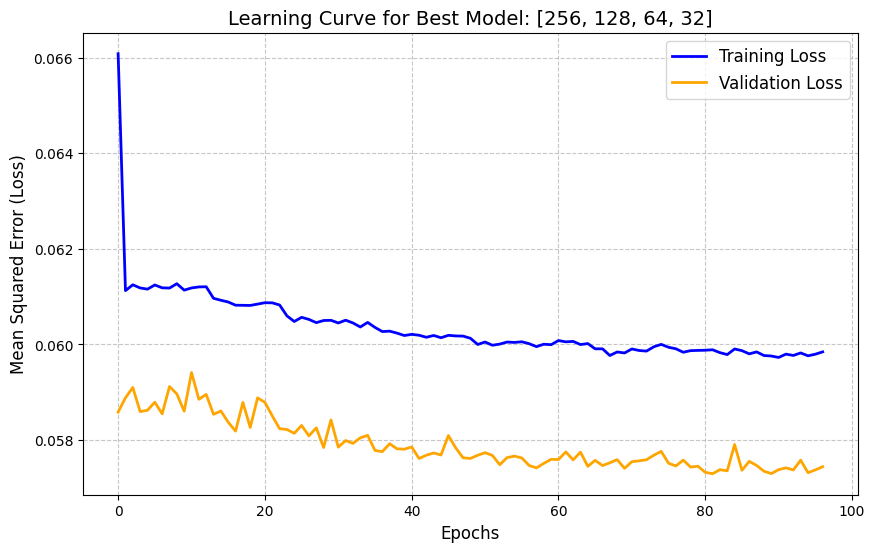

In [ ]:
# 6. Plot the Learning Curve for the Best Model
plt.figure(figsize=(10, 6))
plt.plot(best_history['train_loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(best_history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title(f'Learning Curve for Best Model: {best_config}', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (Loss)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 7. Final Test Evaluation (on the completely unseen test set)

best_model.eval()
with torch.no_grad():
    test_preds = best_model(X_test_t).numpy()

final_r2 = r2_score(y_test.values, test_preds)
print(f"Final Out-of-Sample Test R²: {final_r2:.4f}")

Final Out-of-Sample Test R²: 0.0121


In [ ]:
# 4. Calculate Statistical Metrics

mse = mean_squared_error(y_test, test_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, test_preds)
r2 = r2_score(y_test, test_preds)

print("\n" + "="*40)
print("🏆 Final Test Set Metrics 🏆")
print("="*40)
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f} ({r2*100:.4f}%)")
print("="*40)


🏆 Final Test Set Metrics 🏆
RMSE: 0.232287
MAE:  0.121687
R²:   0.012098 (1.2098%)


In [ ]:
# 5. Save the Model State Dictionary
model_save_path = f"best_nnl_model_1st_attempt_{best_config}.pth"
torch.save(best_model.state_dict(), model_save_path)
print(f"\n✅ Model successfully saved to '{model_save_path}'")



✅ Model successfully saved to 'best_nnl_model_1st_attempt_[256, 128, 64, 32].pth'


## Neural Network (1st Attempt) - Performance Summary

### Model Architecture
* **Best Configuration:** `[256, 128, 64, 32]` (4 hidden layers)
* **Features:** ReLU activation, Batch Normalization, and Dropout (0.4)

### Statistical Metrics
* **RMSE (Root Mean Squared Error):** `0.232287`
* **MAE (Mean Absolute Error):** `0.121687`
* **R² (R-Squared):** `0.012098` (1.21%)

**Metrics Analysis:**
The R² score of 1.21% indicates that the model explains a very small portion of the variance in the target variable (log returns). While predicting financial log returns is notoriously difficult and R² values are typically very low in this domain, this suggests the model has weak predictive power and leaves significant room for improvement through feature engineering or hyperparameter tuning.

### Learning Curve Analysis
* **Convergence:** Both training and validation losses drop sharply in the initial epochs and then stabilize, indicating that the model is learning.
* **Dropout Effect:** The validation loss is consistently *lower* than the training loss. This is a classic signature of using a high Dropout rate (0.4). During training, 40% of the neurons are deactivated, making the task artificially harder and the training loss higher. During validation, all neurons are active, resulting in better performance and a lower loss.
* **Overfitting:** There is no evidence of severe overfitting. The validation curve remains stable and does not start climbing upward as epochs progress. The model effectively plateaus, triggering early stopping.

# Step 4: Fine-tuning

## LeakyReLU

In [682]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [683]:
df = pd.read_parquet('Preprocessed_NNL_data.parquet')

# Split back into Train and Test using the column we created
train_data = df[df['dataset_split'] == 'train'].drop(columns=['dataset_split'])
test_data  = df[df['dataset_split'] == 'test'].drop(columns=['dataset_split'])

# 3. Separate Features (X) and Target (y)
X_train = train_data.drop(columns=['Target'])
y_train = train_data['Target']

X_test = test_data.drop(columns=['Target'])
y_test = test_data['Target']

# 1. Create a Validation Set from the Training Data
# We keep X_test_final completely unseen for the very end.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train.values, y_train.values, test_size=0.2, random_state=42, shuffle=False
)

In [685]:
# 2. Convert to PyTorch Tensors
X_train_t = torch.tensor(X_tr, dtype=torch.float32)
y_train_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


class DynamicNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.2): 
        super(DynamicNet, self).__init__()
        layers = []
        in_d = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_d, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            # Replaced ReLU with LeakyReLU to prevent dying neurons
            layers.append(nn.ReLU() )
            layers.append(nn.Dropout(dropout))
            in_d = h_dim
            
        layers.append(nn.Linear(in_d, 1)) # Output layer (Linear)
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)



In [686]:
# 4. Training Function
def train_model(hidden_layers, lr=0.0005, epochs=150, patience=15):
    # Pass dropout=0.2 to the model instantiation
    model = DynamicNet(X_train_t.shape[1], hidden_layers, dropout=0.2)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for xb, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            train_losses.append(loss.item())
            
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
            
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        
        scheduler.step(val_loss)
        
        # Early stopping based on MSE loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"   Early stopping at epoch {epoch}")
            break
            
    if best_weights is not None:
        model.load_state_dict(best_weights)
        
    # Calculate R^2 on validation set for the best weights of this model
    model.eval()
    with torch.no_grad():
        final_val_preds = model(X_val_t).numpy()
        val_r2 = r2_score(y_val_t.numpy(), final_val_preds)
        
    return model, val_r2, history

In [687]:
# 5. Architecture Search (Structured as NN1 to NN5)
# Using the halving rule for bottleneck compression
architectures = {
    "NN1": [32],
    "NN2": [64, 32],
    "NN3": [128, 64, 32],
    "NN4": [256, 128, 64, 32],
    "NN5": [512, 256, 128, 64, 32]
}

best_model = None
best_config_name = None
best_config_layers = None
highest_r2 = -float('inf') # We want to MAXIMIZE R^2
best_history = None

print("Starting Architecture Search...\n")


Starting Architecture Search...



In [688]:
for name, conf in architectures.items():
    print(f"Training {name} architecture: {conf}")
    model, val_r2, hist = train_model(conf)
    
    # Convert R^2 to percentage for easier reading, matching the paper
    val_r2_pct = val_r2 * 100 
    
    if val_r2 > highest_r2:
        highest_r2 = val_r2
        best_model = model
        best_config_name = name
        best_config_layers = conf
        best_history = hist
        print(f" -> New best! Val R^2: {val_r2_pct:.4f}%")
    else:
        print(f" -> Val R^2: {val_r2_pct:.4f}%")

print(f"\n{'='*50}")
print(f"🏆 Best Architecture: {best_config_name} {best_config_layers}")
print(f"🏆 Best Validation R^2: {highest_r2 * 100:.4f}%")
print(f"{'='*50}\n")


Training NN1 architecture: [32]
   Early stopping at epoch 63
 -> New best! Val R^2: 6.0254%
Training NN2 architecture: [64, 32]
   Early stopping at epoch 61
 -> New best! Val R^2: 8.0343%
Training NN3 architecture: [128, 64, 32]
   Early stopping at epoch 54
 -> New best! Val R^2: 8.9352%
Training NN4 architecture: [256, 128, 64, 32]
   Early stopping at epoch 68
 -> New best! Val R^2: 9.4325%
Training NN5 architecture: [512, 256, 128, 64, 32]
   Early stopping at epoch 111
 -> New best! Val R^2: 9.8933%

🏆 Best Architecture: NN5 [512, 256, 128, 64, 32]
🏆 Best Validation R^2: 9.8933%



In [689]:
# 6. Save the new best model
model_save_path = f"best_nnl_model_2_attempt_leakyrelu_{best_config_layers}.pth"
torch.save(best_model.state_dict(), model_save_path)
print(f"\n✅ Model successfully saved to '{model_save_path}'")


✅ Model successfully saved to 'best_nnl_model_2_attempt_leakyrelu_[512, 256, 128, 64, 32].pth'


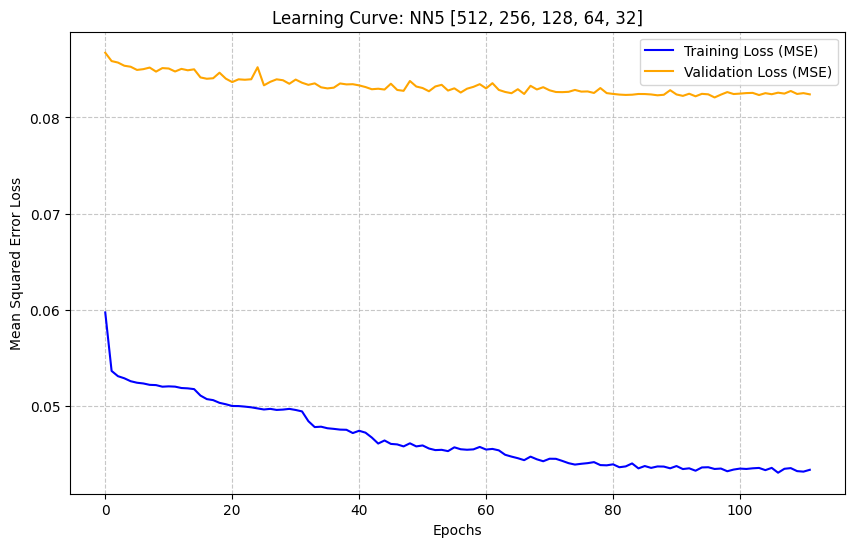

In [690]:
plt.figure(figsize=(10, 6))
plt.plot(best_history['train_loss'], label='Training Loss (MSE)', color='blue')
plt.plot(best_history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title('Learning Curve: NN5 [512, 256, 128, 64, 32]')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [691]:
best_model.eval()
with torch.no_grad():
    test_preds_t = best_model(X_test_t)
    
    # Convert PyTorch tensors back to NumPy arrays so sklearn can use them
    y_test_np = y_test_t.numpy()
    test_preds_np = test_preds_t.numpy()
    

In [692]:
# 3. Compute the metrics
mse = mean_squared_error(y_test_np, test_preds_np)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_np, test_preds_np)
r2_oos = r2_score(y_test_np, test_preds_np)

# 4. Print the results
print("\n" + "="*50)
print("📊 Out-of-Sample (Test Set) Performance")
print("="*50)
print(f"RMSE (Root Mean Squared Error): {rmse:.6f}")
print(f"MAE  (Mean Absolute Error):     {mae:.6f}")
print(f"R^2  (Out-of-Sample):           {r2_oos * 100:.4f}%")
print("="*50)


📊 Out-of-Sample (Test Set) Performance
RMSE (Root Mean Squared Error): 0.234000
MAE  (Mean Absolute Error):     0.125742
R^2  (Out-of-Sample):           -0.2530%


## NN1

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [25]:
df = pd.read_parquet('Preprocessed_NNL_data.parquet')

# Split back into Train and Test using the column we created
train_data = df[df['dataset_split'] == 'train'].drop(columns=['dataset_split'])
test_data  = df[df['dataset_split'] == 'test'].drop(columns=['dataset_split'])

# 3. Separate Features (X) and Target (y)
X_train = train_data.drop(columns=['Target'])
y_train = train_data['Target']

X_test = test_data.drop(columns=['Target'])
y_test = test_data['Target']

# 1. Create a Validation Set from the Training Data
# We keep X_test_final completely unseen for the very end.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train.values, y_train.values, test_size=0.2, random_state=42
)

# 2. Convert to PyTorch Tensors
# (Assuming X_tr, y_tr, X_val, y_val, X_test, y_test are already defined in your environment)
X_train_t = torch.tensor(X_tr, dtype=torch.float32)
y_train_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [26]:
# 3. Model Definition (Using LeakyReLU, BatchNorm, and Dropout)
class DynamicNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.2):
        super(DynamicNet, self).__init__()
        layers = []
        in_d = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_d, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            # Replaced ReLU with LeakyReLU to prevent dying neurons
            layers.append(nn.LeakyReLU(negative_slope=0.01)) 
            layers.append(nn.Dropout(dropout))
            in_d = h_dim
            
        layers.append(nn.Linear(in_d, 1)) # Output layer (Linear)
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)


In [27]:
# 4. Training Function
def train_model(hidden_layers, lr=0.0005, epochs=150, patience=15):
    model = DynamicNet(X_train_t.shape[1], hidden_layers, dropout=0.4)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.HuberLoss(delta=1.0) 
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for xb, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            train_losses.append(loss.item())
            
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
            
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        
        scheduler.step(val_loss)
        
        # Early stopping based on MSE loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"   Early stopping at epoch {epoch}")
            break
            
    if best_weights is not None:
        model.load_state_dict(best_weights)
        
    # Calculate R^2 on validation set for the best weights of this model
    model.eval()
    with torch.no_grad():
        final_val_preds = model(X_val_t).numpy()
        val_r2 = r2_score(y_val_t.numpy(), final_val_preds)
        
    return model, val_r2, history

In [28]:
# 5. Architecture Search (Structured as NN1 to NN5)
# Using the halving rule for bottleneck compression
architectures = {
    "NN1_16_neurons": [16],
    "NN1_32_neurons": [32],
    "NN1_64_neurons": [64],
    "NN1_128_neurons": [128],
    "NN1_256_neurons": [256],
    "NN1_512_neurons": [512]
}

best_model = None
best_config_name = None
best_config_layers = None
highest_r2 = -float('inf') # We want to MAXIMIZE R^2
best_history = None

print("Starting Architecture Search...\n")


Starting Architecture Search...



In [31]:
for name, conf in architectures.items():
    print(f"Training {name} architecture: {conf}")
    # Note: Since these are smaller models, they will train much faster than NN5!
    model, val_r2, hist = train_model(conf)
    
    # Convert R^2 to percentage for easier reading
    val_r2_pct = val_r2 * 100 
    
    if val_r2 > highest_r2:
        highest_r2 = val_r2
        best_model = model
        best_config_name = name
        best_config_layers = conf
        best_history = hist
        print(f" -> New best! Val R^2: {val_r2_pct:.4f}%")
    else:
        print(f" -> Val R^2: {val_r2_pct:.4f}%")

Training NN1_16_neurons architecture: [16]
   Early stopping at epoch 64
 -> Val R^2: 9.3903%
Training NN1_32_neurons architecture: [32]
   Early stopping at epoch 111
 -> New best! Val R^2: 10.1878%
Training NN1_64_neurons architecture: [64]
   Early stopping at epoch 139
 -> New best! Val R^2: 10.5249%
Training NN1_128_neurons architecture: [128]
   Early stopping at epoch 110
 -> New best! Val R^2: 10.8197%
Training NN1_256_neurons architecture: [256]
   Early stopping at epoch 100
 -> New best! Val R^2: 11.0582%
Training NN1_512_neurons architecture: [512]
   Early stopping at epoch 124
 -> New best! Val R^2: 11.1637%


In [32]:
print(f"\n{'='*50}")
print(f"🏆 Best NN1 Architecture: {best_config_name} {best_config_layers}")
print(f"🏆 Best Validation R^2: {highest_r2 * 100:.4f}%")
print(f"{'='*50}\n")


🏆 Best NN1 Architecture: NN1_512_neurons [512]
🏆 Best Validation R^2: 11.1637%



In [33]:
# Ensemble Multiple Initializations
print(f"Starting Ensemble Training for {best_config_name} {best_config_layers}...\n")

num_ensemble = 5
ensemble_models = []
ensemble_histories = []

for i in range(num_ensemble):
    print(f"Training Ensemble Model {i+1}/{num_ensemble}...")
    # Train a new model from scratch using the best configuration
    model, val_r2, hist = train_model(best_config_layers)
    ensemble_models.append(model)
    ensemble_histories.append(hist)
    print(f" -> Model {i+1} finished with Val R2: {val_r2 * 100:.4f}%\n")

Starting Ensemble Training for NN1_512_neurons [512]...

Training Ensemble Model 1/5...
   Early stopping at epoch 123
 -> Model 1 finished with Val R2: 11.1770%

Training Ensemble Model 2/5...
   Early stopping at epoch 114
 -> Model 2 finished with Val R2: 11.2369%

Training Ensemble Model 3/5...
   Early stopping at epoch 89
 -> Model 3 finished with Val R2: 10.9531%

Training Ensemble Model 4/5...
   Early stopping at epoch 109
 -> Model 4 finished with Val R2: 11.3042%

Training Ensemble Model 5/5...
   Early stopping at epoch 110
 -> Model 5 finished with Val R2: 11.3601%



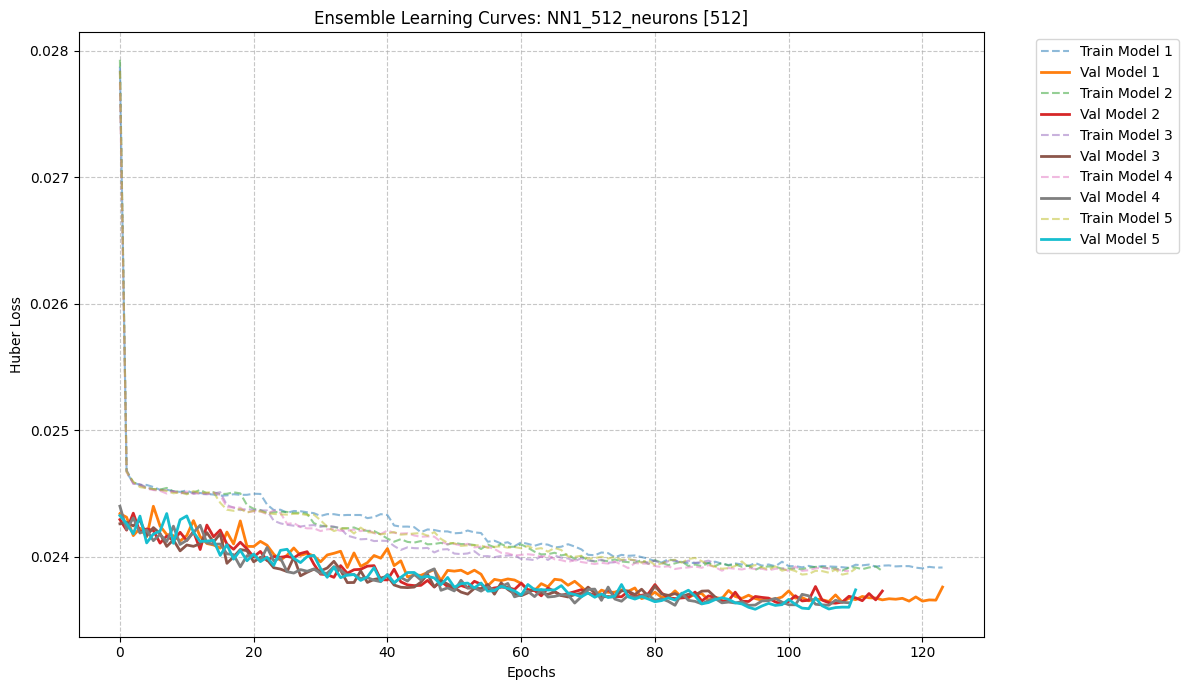

In [34]:
plt.figure(figsize=(12, 7))
for i, hist in enumerate(ensemble_histories):
    plt.plot(hist['train_loss'], linestyle='--', alpha=0.5, label=f'Train Model {i+1}')
    plt.plot(hist['val_loss'], linewidth=2, label=f'Val Model {i+1}')

plt.title(f'Ensemble Learning Curves: {best_config_name} {best_config_layers}')
plt.xlabel('Epochs')
plt.ylabel('Huber Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [35]:
# Save the ensemble models and their histories
checkpoint = {
    'ensemble_state_dicts': [m.state_dict() for m in ensemble_models],
    'ensemble_histories': ensemble_histories,
    'best_config_layers': best_config_layers
}
torch.save(checkpoint, "ensemble_best_NN1.pth")
print("Ensemble models saved to 'ensemble_best_NN1.pth'")

Ensemble models saved to 'ensemble_best_NN1.pth'


In [36]:
# Final Test Evaluation using the Ensemble
print("\nEvaluating Ensemble on Unseen Test Set...")
all_test_preds = []

for model in ensemble_models:
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).numpy()
        all_test_preds.append(preds)

# Average the predictions across all 5 models
ensemble_test_preds = np.mean(all_test_preds, axis=0)

# Calculate Statistical Metrics
mse = mean_squared_error(y_test, ensemble_test_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, ensemble_test_preds)
r2 = r2_score(y_test, ensemble_test_preds)

print("\n" + "="*40)
print("🏆 Final Ensemble Test Set Metrics 🏆")
print("="*40)
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f} ({r2*100:.4f}%)")
print("="*40)


Evaluating Ensemble on Unseen Test Set...

🏆 Final Ensemble Test Set Metrics 🏆
RMSE: 0.238499
MAE:  0.129180
R²:   -0.041443 (-4.1443%)


## NN2

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [38]:
df = pd.read_parquet('Preprocessed_NNL_data.parquet')

# Split back into Train and Test using the column we created
train_data = df[df['dataset_split'] == 'train'].drop(columns=['dataset_split'])
test_data  = df[df['dataset_split'] == 'test'].drop(columns=['dataset_split'])

# 3. Separate Features (X) and Target (y)
X_train = train_data.drop(columns=['Target'])
y_train = train_data['Target']

X_test = test_data.drop(columns=['Target'])
y_test = test_data['Target']

# 1. Create a Validation Set from the Training Data
# We keep X_test_final completely unseen for the very end.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train.values, y_train.values, test_size=0.2, random_state=42
)

# 2. Convert to PyTorch Tensors
# (Assuming X_tr, y_tr, X_val, y_val, X_test, y_test are already defined in your environment)
X_train_t = torch.tensor(X_tr, dtype=torch.float32)
y_train_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [ ]:
# 3. Model Definition (Using LeakyReLU, BatchNorm, and Dropout)
class DynamicNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.2):
        super(DynamicNet, self).__init__()
        layers = []
        in_d = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_d, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            # Replaced ReLU with LeakyReLU to prevent dying neurons
            layers.append(nn.LeakyReLU(negative_slope=0.01)) 
            layers.append(nn.Dropout(dropout))
            in_d = h_dim
            
        layers.append(nn.Linear(in_d, 1)) # Output layer (Linear)
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)


In [39]:
# 4. Training Function
def train_model(hidden_layers, lr=0.0005, epochs=150, patience=15):
    model = DynamicNet(X_train_t.shape[1], hidden_layers, dropout=0.4)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.HuberLoss(delta=1.0) 
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for xb, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            train_losses.append(loss.item())
            
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
            
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        
        scheduler.step(val_loss)
        
        # Early stopping based on MSE loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"   Early stopping at epoch {epoch}")
            break
            
    if best_weights is not None:
        model.load_state_dict(best_weights)
        
    # Calculate R^2 on validation set for the best weights of this model
    model.eval()
    with torch.no_grad():
        final_val_preds = model(X_val_t).numpy()
        val_r2 = r2_score(y_val_t.numpy(), final_val_preds)
        
    return model, val_r2, history

In [ ]:
architectures = {
    "NN2_16_start": [16, 8],
    "NN2_32_start": [32, 16],
    "NN2_64_start": [64, 32],
    "NN2_128_start": [128, 64],
    "NN2_256_start": [256, 128],
    "NN2_512_start": [512, 256]
}

best_model = None
best_config_name = None
best_config_layers = None
highest_r2 = -float('inf') # We want to MAXIMIZE R^2
best_history = None

print("Starting Architecture Search for NN2...\n")

Starting Architecture Search for NN2...



In [41]:
for name, conf in architectures.items():
    print(f"Training {name} architecture: {conf}")
    # Note: Since these are smaller models, they will train much faster than NN5!
    model, val_r2, hist = train_model(conf)
    
    # Convert R^2 to percentage for easier reading
    val_r2_pct = val_r2 * 100 
    
    if val_r2 > highest_r2:
        highest_r2 = val_r2
        best_model = model
        best_config_name = name
        best_config_layers = conf
        best_history = hist
        print(f" -> New best! Val R^2: {val_r2_pct:.4f}%")
    else:
        print(f" -> Val R^2: {val_r2_pct:.4f}%")

Training NN2_16_start architecture: [16, 8]
   Early stopping at epoch 101
 -> New best! Val R^2: 9.3613%
Training NN2_32_start architecture: [32, 16]
   Early stopping at epoch 97
 -> New best! Val R^2: 10.4426%
Training NN2_64_start architecture: [64, 32]
   Early stopping at epoch 100
 -> New best! Val R^2: 11.7459%
Training NN2_128_start architecture: [128, 64]
   Early stopping at epoch 82
 -> New best! Val R^2: 13.8145%
Training NN2_256_start architecture: [256, 128]
   Early stopping at epoch 129
 -> New best! Val R^2: 16.0401%
Training NN2_512_start architecture: [512, 256]
 -> New best! Val R^2: 17.4214%


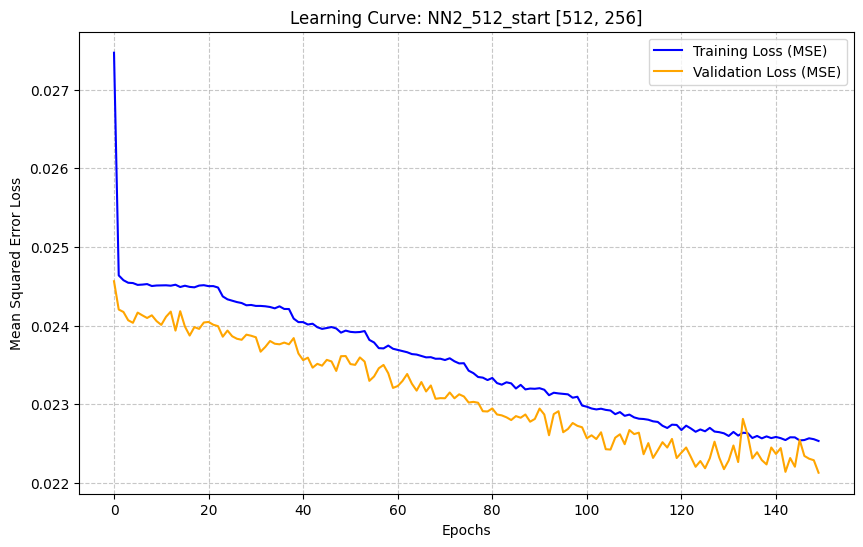

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(best_history['train_loss'], label='Training Loss (MSE)', color='blue')
plt.plot(best_history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title(f'Learning Curve: {best_config_name} {best_config_layers}')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [43]:
# Ensemble Multiple Initializations
print(f"Starting Ensemble Training for {best_config_name} {best_config_layers}...\n")

num_ensemble = 5
ensemble_models = []
ensemble_histories = []

for i in range(num_ensemble):
    print(f"Training Ensemble Model {i+1}/{num_ensemble}...")
    # Train a new model from scratch using the best configuration
    model, val_r2, hist = train_model(best_config_layers)
    ensemble_models.append(model)
    ensemble_histories.append(hist)
    print(f" -> Model {i+1} finished with Val R2: {val_r2 * 100:.4f}%\n")

Starting Ensemble Training for NN2_512_start [512, 256]...

Training Ensemble Model 1/5...
   Early stopping at epoch 148
 -> Model 1 finished with Val R2: 17.3645%

Training Ensemble Model 2/5...
 -> Model 2 finished with Val R2: 16.8832%

Training Ensemble Model 3/5...
 -> Model 3 finished with Val R2: 17.3079%

Training Ensemble Model 4/5...
 -> Model 4 finished with Val R2: 17.3189%

Training Ensemble Model 5/5...
 -> Model 5 finished with Val R2: 17.2213%



In [44]:
# Final Test Evaluation using the Ensemble
print("\nEvaluating Ensemble on Unseen Test Set...")
all_test_preds = []

for model in ensemble_models:
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).numpy()
        all_test_preds.append(preds)

# Average the predictions across all 5 models
ensemble_test_preds = np.mean(all_test_preds, axis=0)

# Calculate Statistical Metrics
mse = mean_squared_error(y_test, ensemble_test_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, ensemble_test_preds)
r2 = r2_score(y_test, ensemble_test_preds)

print("\n" + "="*40)
print("🏆 Final Ensemble Test Set Metrics 🏆")
print("="*40)
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f} ({r2*100:.4f}%)")
print("="*40)


Evaluating Ensemble on Unseen Test Set...

🏆 Final Ensemble Test Set Metrics 🏆
RMSE: 0.234693
MAE:  0.122087
R²:   -0.008475 (-0.8475%)


In [45]:
# Save the ensemble models and their histories
checkpoint = {
    'ensemble_state_dicts': [m.state_dict() for m in ensemble_models],
    'ensemble_histories': ensemble_histories,
    'best_config_layers': best_config_layers
}
torch.save(checkpoint, "ensemble_best_NN2.pth")
print("Ensemble models saved to 'ensemble_best_NN2.pth'")

Ensemble models saved to 'ensemble_best_NN2.pth'


## NN3

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_parquet('Preprocessed_NNL_data.parquet')


In [3]:
# Split back into Train and Test using the column we created
train_data = df[df['dataset_split'] == 'train'].drop(columns=['dataset_split'])
test_data  = df[df['dataset_split'] == 'test'].drop(columns=['dataset_split'])

# 3. Separate Features (X) and Target (y)
X_train = train_data.drop(columns=['Target'])
y_train = train_data['Target']

X_test = test_data.drop(columns=['Target'])
y_test = test_data['Target']

# 1. Create a Validation Set from the Training Data
# We keep X_test_final completely unseen for the very end.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train.values, y_train.values, test_size=0.2, random_state=42
)

# 2. Convert to PyTorch Tensors
# (Assuming X_tr, y_tr, X_val, y_val, X_test, y_test are already defined in your environment)
X_train_t = torch.tensor(X_tr, dtype=torch.float32)
y_train_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [4]:
# 3. Model Definition (Using LeakyReLU, BatchNorm, and Dropout)
class DynamicNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.2):
        super(DynamicNet, self).__init__()
        layers = []
        in_d = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_d, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            # Replaced ReLU with LeakyReLU to prevent dying neurons
            layers.append(nn.LeakyReLU(negative_slope=0.01)) 
            layers.append(nn.Dropout(dropout))
            in_d = h_dim
            
        layers.append(nn.Linear(in_d, 1)) # Output layer (Linear)
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

# 4. Training Function
def train_model(hidden_layers, lr=0.0005, epochs=150, patience=15):
    model = DynamicNet(X_train_t.shape[1], hidden_layers, dropout=0.2)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.HuberLoss(delta=1.0) 
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for xb, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            train_losses.append(loss.item())
            
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
            
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        
        scheduler.step(val_loss)
        
        # Early stopping based on MSE loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"   Early stopping at epoch {epoch}")
            break
            
    if best_weights is not None:
        model.load_state_dict(best_weights)
        
    # Calculate R^2 on validation set for the best weights of this model
    model.eval()
    with torch.no_grad():
        final_val_preds = model(X_val_t).numpy()
        val_r2 = r2_score(y_val_t.numpy(), final_val_preds)
        
    return model, val_r2, history

In [51]:
architectures = {
    "NN3_128_start": [128, 64, 32],
    "NN3_256_start": [256, 128, 64],
    "NN3_512_start": [512, 256, 128]
}

best_model = None
best_config_name = None
best_config_layers = None
highest_r2 = -float('inf') # We want to MAXIMIZE R^2
best_history = None

print("Starting Architecture Search for NN3...\n")

Starting Architecture Search for NN3...



In [52]:
for name, conf in architectures.items():
    print(f"Training {name} architecture: {conf}")
    # Note: Since these are smaller models, they will train much faster than NN5!
    model, val_r2, hist = train_model(conf)
    
    # Convert R^2 to percentage for easier reading
    val_r2_pct = val_r2 * 100 
    
    if val_r2 > highest_r2:
        highest_r2 = val_r2
        best_model = model
        best_config_name = name
        best_config_layers = conf
        best_history = hist
        print(f" -> New best! Val R^2: {val_r2_pct:.4f}%")
    else:
        print(f" -> Val R^2: {val_r2_pct:.4f}%")


Training NN3_128_start architecture: [128, 64, 32]
   Early stopping at epoch 125
 -> New best! Val R^2: 14.1266%
Training NN3_256_start architecture: [256, 128, 64]
   Early stopping at epoch 124
 -> New best! Val R^2: 17.6981%
Training NN3_512_start architecture: [512, 256, 128]
 -> New best! Val R^2: 17.8107%


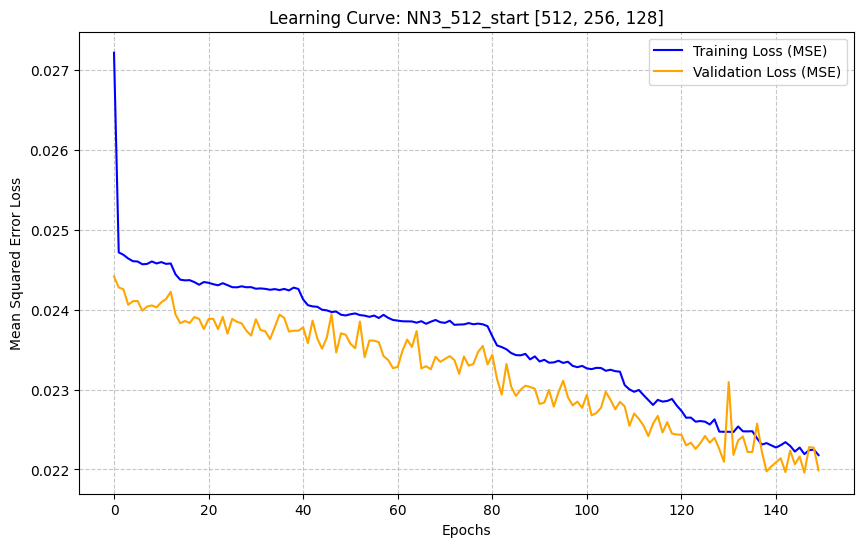

In [53]:
plt.figure(figsize=(10, 6))
plt.plot(best_history['train_loss'], label='Training Loss (MSE)', color='blue')
plt.plot(best_history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title(f'Learning Curve: {best_config_name} {best_config_layers}')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [55]:
# Final Test Evaluation (Out-of-Sample)

# 1. Set the model to evaluation mode (disables dropout, sets batchnorm to eval mode)
best_model.eval()

# 2. Make predictions without tracking gradients (saves memory and computation)
with torch.no_grad():
    test_preds = best_model(X_test_t).numpy()

# 3. Compute Statistical Metrics
mse = mean_squared_error(y_test, test_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, test_preds)
out_of_sample_r2 = r2_score(y_test, test_preds)

# 4. Display the Results
print("\n" + "="*40)
print(f"🏆 Final Test Set Metrics ({best_config_name}) 🏆")
print("="*40)
print(f"RMSE:             {rmse:.6f}")
print(f"MAE:              {mae:.6f}")
print(f"Out-of-Sample R²: {out_of_sample_r2:.6f} ({out_of_sample_r2 * 100:.4f}%)")
print("="*40)


🏆 Final Test Set Metrics (NN3_512_start) 🏆
RMSE:             0.230730
MAE:              0.119891
Out-of-Sample R²: 0.025300 (2.5300%)


In [56]:
# How to save BOTH weights and history
checkpoint = {
    'model_state_dict': best_model.state_dict(),
    'history': best_history
}
torch.save(checkpoint, "best_NN3.pth")

In [5]:
best_config_name = "NN3_512_start"

best_config_layers = [512, 256, 128]


In [6]:
# Ensemble Multiple Initializations
print(f"Starting Ensemble Training for {best_config_name} {best_config_layers}...\n")

num_ensemble = 5
ensemble_models = []
ensemble_histories = []

for i in range(num_ensemble):
    print(f"Training Ensemble Model {i+1}/{num_ensemble}...")
    # Train a new model from scratch using the best configuration
    model, val_r2, hist = train_model(best_config_layers)
    ensemble_models.append(model)
    ensemble_histories.append(hist)
    print(f" -> Model {i+1} finished with Val R2: {val_r2 * 100:.4f}%\n")


Starting Ensemble Training for NN3_512_start [512, 256, 128]...

Training Ensemble Model 1/5...
 -> Model 1 finished with Val R2: 19.8452%

Training Ensemble Model 2/5...
 -> Model 2 finished with Val R2: 20.5508%

Training Ensemble Model 3/5...
   Early stopping at epoch 140
 -> Model 3 finished with Val R2: 20.2401%

Training Ensemble Model 4/5...
 -> Model 4 finished with Val R2: 20.7706%

Training Ensemble Model 5/5...
 -> Model 5 finished with Val R2: 19.4483%



In [7]:
# Final Test Evaluation using the Ensemble
print("\nEvaluating Ensemble on Unseen Test Set...")
all_test_preds = []

for model in ensemble_models:
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).numpy()
        all_test_preds.append(preds)

# Average the predictions across all 5 models
ensemble_test_preds = np.mean(all_test_preds, axis=0)

# Calculate Statistical Metrics
mse = mean_squared_error(y_test, ensemble_test_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, ensemble_test_preds)
r2 = r2_score(y_test, ensemble_test_preds)

print("\n" + "="*40)
print("🏆 Final Ensemble Test Set Metrics 🏆")
print("="*40)
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f} ({r2*100:.4f}%)")
print("="*40)


Evaluating Ensemble on Unseen Test Set...

🏆 Final Ensemble Test Set Metrics 🏆
RMSE: 0.233469
MAE:  0.120539
R²:   0.002018 (0.2018%)


In [8]:
# Save the ensemble models and their histories
checkpoint = {
    'ensemble_state_dicts': [m.state_dict() for m in ensemble_models],
    'ensemble_histories': ensemble_histories,
    'best_config_layers': best_config_layers
}
torch.save(checkpoint, "ensemble_best_NN3.pth")
print("Ensemble models saved to 'ensemble_best_NN3.pth'")

Ensemble models saved to 'ensemble_best_NN3.pth'


## NN4

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [10]:
df = pd.read_parquet('Preprocessed_NNL_data.parquet')

In [11]:
# Split back into Train and Test using the column we created
train_data = df[df['dataset_split'] == 'train'].drop(columns=['dataset_split'])
test_data  = df[df['dataset_split'] == 'test'].drop(columns=['dataset_split'])

# 3. Separate Features (X) and Target (y)
X_train = train_data.drop(columns=['Target'])
y_train = train_data['Target']

X_test = test_data.drop(columns=['Target'])
y_test = test_data['Target']

# 1. Create a Validation Set from the Training Data
# We keep X_test_final completely unseen for the very end.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train.values, y_train.values, test_size=0.1, random_state=42
)

# 2. Convert to PyTorch Tensors
# (Assuming X_tr, y_tr, X_val, y_val, X_test, y_test are already defined in your environment)
X_train_t = torch.tensor(X_tr, dtype=torch.float32)
y_train_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


In [12]:
# 3. Model Definition (Using LeakyReLU, BatchNorm, and Dropout)
class DynamicNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.2):
        super(DynamicNet, self).__init__()
        layers = []
        in_d = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_d, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            # Replaced ReLU with LeakyReLU to prevent dying neurons
            layers.append(nn.LeakyReLU(negative_slope=0.01)) 
            layers.append(nn.Dropout(dropout))
            in_d = h_dim
            
        layers.append(nn.Linear(in_d, 1)) # Output layer (Linear)
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)


In [13]:
# 4. Training Function
def train_model(hidden_layers, lr=0.0005, epochs=150, patience=15):
    model = DynamicNet(X_train_t.shape[1], hidden_layers, dropout=0.2)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.HuberLoss(delta=1.0) 
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for xb, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            train_losses.append(loss.item())
            
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
            
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        
        scheduler.step(val_loss)
        
        # Early stopping based on MSE loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"   Early stopping at epoch {epoch}")
            break
            
    if best_weights is not None:
        model.load_state_dict(best_weights)
        
    # Calculate R^2 on validation set for the best weights of this model
    model.eval()
    with torch.no_grad():
        final_val_preds = model(X_val_t).numpy()
        val_r2 = r2_score(y_val_t.numpy(), final_val_preds)
        
    return model, val_r2, history

In [14]:
architectures = {
    "NN4_256_start": [256, 128, 64, 32],
    "NN4_512_start": [512, 256, 128, 64],
    "NN4_1024_start": [1024, 512, 256, 128]
}

best_model = None
best_config_name = None
best_config_layers = None
highest_r2 = -float('inf') # We want to MAXIMIZE R^2
best_history = None

print("Starting Architecture Search for NN4...\n")

Starting Architecture Search for NN4...



In [15]:
for name, conf in architectures.items():
    print(f"Training {name} architecture: {conf}")
    # Note: Since these are smaller models, they will train much faster than NN5!
    model, val_r2, hist = train_model(conf)
    
    # Convert R^2 to percentage for easier reading
    val_r2_pct = val_r2 * 100 
    
    if val_r2 > highest_r2:
        highest_r2 = val_r2
        best_model = model
        best_config_name = name
        best_config_layers = conf
        best_history = hist
        print(f" -> New best! Val R^2: {val_r2_pct:.4f}%")
    else:
        print(f" -> Val R^2: {val_r2_pct:.4f}%")

Training NN4_256_start architecture: [256, 128, 64, 32]
   Early stopping at epoch 125
 -> New best! Val R^2: 20.5485%
Training NN4_512_start architecture: [512, 256, 128, 64]
 -> New best! Val R^2: 22.2159%
Training NN4_1024_start architecture: [1024, 512, 256, 128]
   Early stopping at epoch 48
 -> Val R^2: 12.3460%


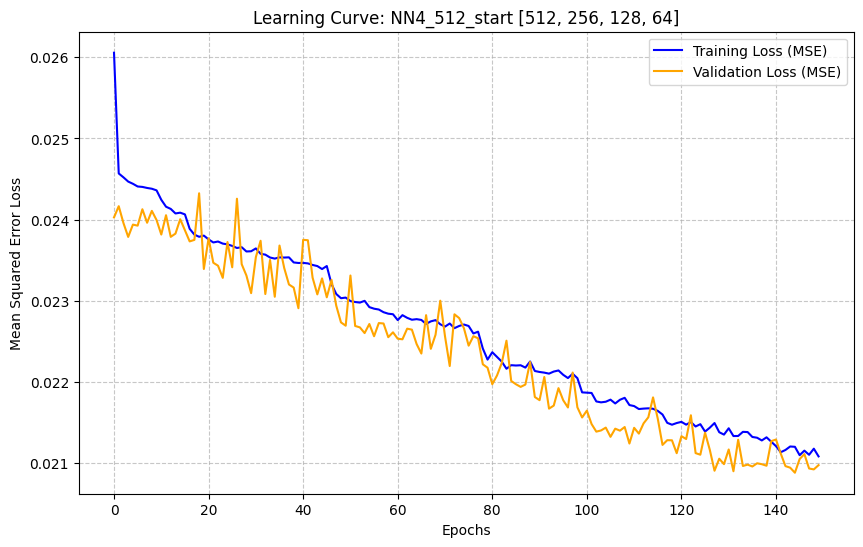

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(best_history['train_loss'], label='Training Loss (MSE)', color='blue')
plt.plot(best_history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title(f'Learning Curve: {best_config_name} {best_config_layers}')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [17]:
# Final Test Evaluation (Out-of-Sample)

# 1. Set the model to evaluation mode (disables dropout, sets batchnorm to eval mode)
best_model.eval()

# 2. Make predictions without tracking gradients (saves memory and computation)
with torch.no_grad():
    test_preds = best_model(X_test_t).numpy()

# 3. Compute Statistical Metrics
mse = mean_squared_error(y_test, test_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, test_preds)
out_of_sample_r2 = r2_score(y_test, test_preds)

# 4. Display the Results
print("\n" + "="*40)
print(f"🏆 Final Test Set Metrics ({best_config_name}) 🏆")
print("="*40)
print(f"RMSE:             {rmse:.6f}")
print(f"MAE:              {mae:.6f}")
print(f"Out-of-Sample R²: {out_of_sample_r2:.6f} ({out_of_sample_r2 * 100:.4f}%)")
print("="*40)

# How to save BOTH weights and history
checkpoint = {
    'model_state_dict': best_model.state_dict(),
    'history': best_history
}
torch.save(checkpoint, "best_NN4.pth")


🏆 Final Test Set Metrics (NN4_512_start) 🏆
RMSE:             0.234001
MAE:              0.122652
Out-of-Sample R²: -0.002534 (-0.2534%)


In [18]:
# Ensemble Multiple Initializations
print(f"Starting Ensemble Training for {best_config_name} {best_config_layers}...\n")

num_ensemble = 3
ensemble_models = []
ensemble_histories = []

for i in range(num_ensemble):
    print(f"Training Ensemble Model {i+1}/{num_ensemble}...")
    # Train a new model from scratch using the best configuration
    model, val_r2, hist = train_model(best_config_layers)
    ensemble_models.append(model)
    ensemble_histories.append(hist)
    print(f" -> Model {i+1} finished with Val R2: {val_r2 * 100:.4f}%\n")


Starting Ensemble Training for NN4_512_start [512, 256, 128, 64]...

Training Ensemble Model 1/3...
   Early stopping at epoch 44
 -> Model 1 finished with Val R2: 11.3589%

Training Ensemble Model 2/3...
 -> Model 2 finished with Val R2: 21.7625%

Training Ensemble Model 3/3...
 -> Model 3 finished with Val R2: 22.5092%



In [19]:
# Final Test Evaluation using the Ensemble
print("\nEvaluating Ensemble on Unseen Test Set...")
all_test_preds = []

for model in ensemble_models:
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).numpy()
        all_test_preds.append(preds)

# Average the predictions across all 5 models
ensemble_test_preds = np.mean(all_test_preds, axis=0)

# Calculate Statistical Metrics
mse = mean_squared_error(y_test, ensemble_test_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, ensemble_test_preds)
r2 = r2_score(y_test, ensemble_test_preds)

print("\n" + "="*40)
print("🏆 Final Ensemble Test Set Metrics 🏆")
print("="*40)
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f} ({r2*100:.4f}%)")
print("="*40)


Evaluating Ensemble on Unseen Test Set...

🏆 Final Ensemble Test Set Metrics 🏆
RMSE: 0.234673
MAE:  0.120615
R²:   -0.008297 (-0.8297%)


In [20]:
# Save the ensemble models and their histories
checkpoint = {
    'ensemble_state_dicts': [m.state_dict() for m in ensemble_models],
    'ensemble_histories': ensemble_histories,
    'best_config_layers': best_config_layers
}
torch.save(checkpoint, "ensemble_best_NN4.pth")
print("Ensemble models saved to 'ensemble_best_NN4.pth'")

Ensemble models saved to 'ensemble_best_NN4.pth'


## NN5

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [22]:
df = pd.read_parquet('Preprocessed_NNL_data.parquet')

In [23]:
# Split back into Train and Test using the column we created
train_data = df[df['dataset_split'] == 'train'].drop(columns=['dataset_split'])
test_data  = df[df['dataset_split'] == 'test'].drop(columns=['dataset_split'])

# 3. Separate Features (X) and Target (y)
X_train = train_data.drop(columns=['Target'])
y_train = train_data['Target']

X_test = test_data.drop(columns=['Target'])
y_test = test_data['Target']

# 1. Create a Validation Set from the Training Data
# We keep X_test_final completely unseen for the very end.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train.values, y_train.values, test_size=0.1, random_state=42
)

# 2. Convert to PyTorch Tensors
# (Assuming X_tr, y_tr, X_val, y_val, X_test, y_test are already defined in your environment)
X_train_t = torch.tensor(X_tr, dtype=torch.float32)
y_train_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


In [24]:
# 3. Model Definition (Using LeakyReLU, BatchNorm, and Dropout)
class DynamicNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.2):
        super(DynamicNet, self).__init__()
        layers = []
        in_d = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_d, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            # Replaced ReLU with LeakyReLU to prevent dying neurons
            layers.append(nn.LeakyReLU(negative_slope=0.01)) 
            layers.append(nn.Dropout(dropout))
            in_d = h_dim
            
        layers.append(nn.Linear(in_d, 1)) # Output layer (Linear)
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

In [25]:
# 4. Training Function
def train_model(hidden_layers, lr=0.0005, epochs=150, patience=15):
    model = DynamicNet(X_train_t.shape[1], hidden_layers, dropout=0.2)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.HuberLoss(delta=1.0) 
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for xb, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            train_losses.append(loss.item())
            
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
            
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        
        scheduler.step(val_loss)
        
        # Early stopping based on MSE loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"   Early stopping at epoch {epoch}")
            break
            
    if best_weights is not None:
        model.load_state_dict(best_weights)
        
    # Calculate R^2 on validation set for the best weights of this model
    model.eval()
    with torch.no_grad():
        final_val_preds = model(X_val_t).numpy()
        val_r2 = r2_score(y_val_t.numpy(), final_val_preds)
        
    return model, val_r2, history

In [26]:
architectures = {
    "NN5_256_start": [256, 128, 64, 32, 16],
    "NN5_512_start": [512, 256, 128, 64, 32],
    "NN5_1024_start": [1024, 512, 256, 128, 64],
}

best_model = None
best_config_name = None
best_config_layers = None
highest_r2 = -float('inf') # We want to MAXIMIZE R^2
best_history = None


In [27]:
print("Starting Architecture Search for NN5...\n")

for name, conf in architectures.items():
    print(f"Training {name} architecture: {conf}")
    # Note: Since these are smaller models, they will train much faster than NN5!
    model, val_r2, hist = train_model(conf)
    
    # Convert R^2 to percentage for easier reading
    val_r2_pct = val_r2 * 100 
    
    if val_r2 > highest_r2:
        highest_r2 = val_r2
        best_model = model
        best_config_name = name
        best_config_layers = conf
        best_history = hist
        print(f" -> New best! Val R^2: {val_r2_pct:.4f}%")
    else:
        print(f" -> Val R^2: {val_r2_pct:.4f}%")

Starting Architecture Search for NN5...

Training NN5_256_start architecture: [256, 128, 64, 32, 16]
   Early stopping at epoch 134
 -> New best! Val R^2: 20.6156%
Training NN5_512_start architecture: [512, 256, 128, 64, 32]
 -> New best! Val R^2: 22.1140%
Training NN5_1024_start architecture: [1024, 512, 256, 128, 64]
 -> New best! Val R^2: 23.0479%


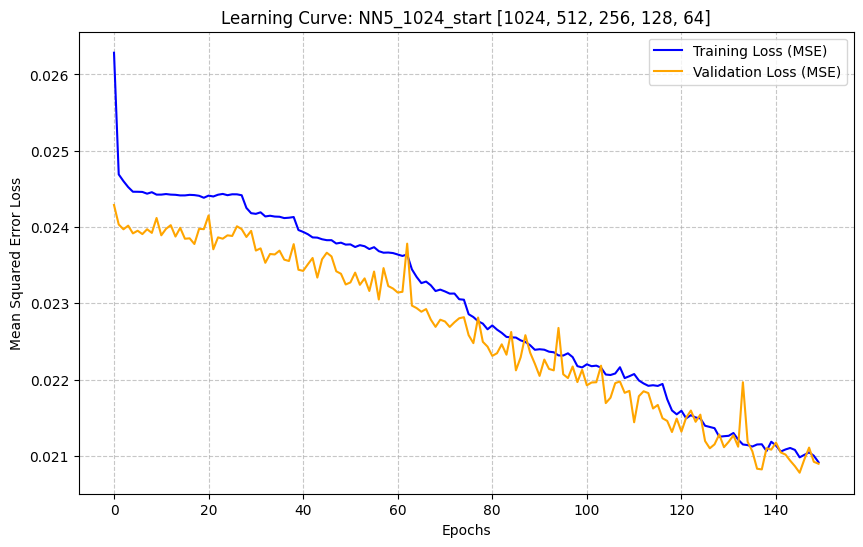

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(best_history['train_loss'], label='Training Loss (MSE)', color='blue')
plt.plot(best_history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title(f'Learning Curve: {best_config_name} {best_config_layers}')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [29]:
# Final Test Evaluation (Out-of-Sample)

# 1. Set the model to evaluation mode (disables dropout, sets batchnorm to eval mode)
best_model.eval()

# 2. Make predictions without tracking gradients (saves memory and computation)
with torch.no_grad():
    test_preds = best_model(X_test_t).numpy()

# 3. Compute Statistical Metrics
mse = mean_squared_error(y_test, test_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, test_preds)
out_of_sample_r2 = r2_score(y_test, test_preds)

# 4. Display the Results
print("\n" + "="*40)
print(f"🏆 Final Test Set Metrics ({best_config_name}) 🏆")
print("="*40)
print(f"RMSE:             {rmse:.6f}")
print(f"MAE:              {mae:.6f}")
print(f"Out-of-Sample R²: {out_of_sample_r2:.6f} ({out_of_sample_r2 * 100:.4f}%)")
print("="*40)

# How to save BOTH weights and history
checkpoint = {
    'model_state_dict': best_model.state_dict(),
    'history': best_history
}
torch.save(checkpoint, "best_NN5.pth")


🏆 Final Test Set Metrics (NN5_1024_start) 🏆
RMSE:             0.230638
MAE:              0.120362
Out-of-Sample R²: 0.026079 (2.6079%)


In [31]:
# Ensemble Multiple Initializations
print(f"Starting Ensemble Training for {best_config_name} {best_config_layers}...\n")

num_ensemble = 2
ensemble_models = []
ensemble_histories = []

for i in range(num_ensemble):
    print(f"Training Ensemble Model {i+1}/{num_ensemble}...")
    # Train a new model from scratch using the best configuration
    model, val_r2, hist = train_model(best_config_layers)
    ensemble_models.append(model)
    ensemble_histories.append(hist)
    print(f" -> Model {i+1} finished with Val R2: {val_r2 * 100:.4f}%\n")


Starting Ensemble Training for NN5_1024_start [1024, 512, 256, 128, 64]...

Training Ensemble Model 1/2...
 -> Model 1 finished with Val R2: 21.7696%

Training Ensemble Model 2/2...
 -> Model 2 finished with Val R2: 24.6993%



In [32]:
# Final Test Evaluation using the Ensemble
print("\nEvaluating Ensemble on Unseen Test Set...")
all_test_preds = []

for model in ensemble_models:
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).numpy()
        all_test_preds.append(preds)

# Average the predictions across all 5 models
ensemble_test_preds = np.mean(all_test_preds, axis=0)

# Calculate Statistical Metrics
mse = mean_squared_error(y_test, ensemble_test_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, ensemble_test_preds)
r2 = r2_score(y_test, ensemble_test_preds)

print("\n" + "="*40)
print("🏆 Final Ensemble Test Set Metrics 🏆")
print("="*40)
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.6f} ({r2*100:.4f}%)")
print("="*40)


Evaluating Ensemble on Unseen Test Set...

🏆 Final Ensemble Test Set Metrics 🏆
RMSE: 0.233003
MAE:  0.120824
R²:   0.005997 (0.5997%)


In [33]:
# Save the ensemble models and their histories
checkpoint = {
    'ensemble_state_dicts': [m.state_dict() for m in ensemble_models],
    'ensemble_histories': ensemble_histories,
    'best_config_layers': best_config_layers
}
torch.save(checkpoint, "ensemble_best_NN5.pth")
print("Ensemble models saved to 'ensemble_best_NN5.pth'")

Ensemble models saved to 'ensemble_best_NN5.pth'


# Step 5: Conduct Investment Portfolio

## Data Preprocessing

In [625]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [693]:
# 1. Define the exact class used during training
class DynamicNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.2):
        super(DynamicNet, self).__init__()
        layers = []
        in_d = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_d, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            # Replaced ReLU with LeakyReLU to prevent dying neurons
            layers.append(nn.ReLU()) 
            layers.append(nn.Dropout(dropout))
            in_d = h_dim
            
        layers.append(nn.Linear(in_d, 1)) # Output layer (Linear)
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

In [694]:
df = pd.read_parquet('Preprocessed_NNL_data.parquet')

# Split back into Train and Test using the column we created
train_data = df[df['dataset_split'] == 'train'].drop(columns=['dataset_split'])
test_data  = df[df['dataset_split'] == 'test'].drop(columns=['dataset_split'])

# 3. Separate Features (X) and Target (y)
X_train = train_data.drop(columns=['Target'])
y_train = train_data['Target']

X_test = test_data.drop(columns=['Target'])
y_test = test_data['Target']

# 1. Create a Validation Set from the Training Data
# We keep X_test_final completely unseen for the very end.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train.values, y_train.values, test_size=0.1, random_state=42
)

# 2. Convert to PyTorch Tensors
# (Assuming X_tr, y_tr, X_val, y_val, X_test, y_test are already defined in your environment)
X_train_t = torch.tensor(X_tr, dtype=torch.float32)
y_train_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


In [695]:
# 2. Get the input size
INPUT_SIZE = X_train_t.shape[1]

# 3. Instantiate the model using the BEST architecture found
best_architecture = [512, 256, 128, 64, 32]
model = DynamicNet(input_dim=INPUT_SIZE, hidden_layers=best_architecture, dropout=0.2)

# 4. Load the checkpoint
checkpoint = torch.load('best_nnl_model_2_attempt_leakyrelu_[512, 256, 128, 64, 32].pth')

# 5. Extract the state_dict and load it into the model
model.load_state_dict(checkpoint)

# 6. Set to evaluation mode
model.eval()

print("Model successfully loaded and ready for inference!")

Model successfully loaded and ready for inference!


In [696]:
# Load Stock Data (Assuming you have a dataframe with 'Date', 'Instrument', 'Target_Forward_Log_Return', and features)
df_stocks = pd.read_parquet('Preprocessed_NNL_data.parquet')

# 2. Define columns to exclude from the tensor
exclude_cols = ['Target', 'dataset_split', 'Date', 'Instrument', 'Target_Forward_Log_Return']

# 3. Extract only the feature columns
feature_cols = [col for col in df_stocks.columns if col not in exclude_cols]

# 4. Convert the features to a numpy array of type float32, then to a PyTorch tensor
# Forcing .astype(np.float32) guarantees we don't pass any object types to PyTorch
X_numpy = df_stocks[feature_cols].astype(np.float32).values
X_tensor = torch.tensor(X_numpy, dtype=torch.float32)

In [697]:
# 5. Predict log returns
model.eval() # Always set the model to evaluation mode before inference
with torch.no_grad():
    # The model outputs shape (N, 1), so we flatten it to (N,) to match the dataframe column
    df_stocks['predicted_log_return'] = model(X_tensor).numpy().flatten()

# Check the results!
print(df_stocks[['Target', 'predicted_log_return', 'dataset_split']].head())

      Target  predicted_log_return dataset_split
12 -0.090972              0.004240         train
13 -0.144934             -0.091942         train
14  0.062242              0.029527         train
15 -0.023257              0.065234         train
16  0.000000              0.010248         train


In [698]:
df_stocks.to_parquet('nn5_predicted_stocks.parquet')

In [699]:
# Load the original dataframe
df_original = pd.read_parquet('hk_stock_data_final.parquet')

In [700]:
df_stocks = df_stocks.join(df_original[['Date', 'Instrument']])

In [701]:
df_stocks.to_parquet('nn5_predicted_stocks_with_dates.parquet')

## Construct the Long/Short Portfolio

In [702]:
df_stocks = pd.read_parquet('nn3_predicted_stocks_with_dates.parquet')
df_baseline = pd.read_csv('HSI&1M1HIBOR_returns_2021_to_2025.csv')

In [703]:
# Convert the actual target log returns to simple returns for accurate portfolio math
df_stocks['actual_simple_return'] = np.exp(df_stocks['Target']) - 1

In [704]:
def get_long_short_return(group, transaction_cost_bps=7):
    """
    Calculates L/S returns with basic reality checks:
    1. Removes extreme outliers (e.g., > 100% in a single month) which are often data errors or uninvestable penny stock jumps.
    2. Applies a transaction cost (in basis points) to simulate trading friction and bid-ask spread.
    """
    # 1. Optional but recommended: Filter out extreme actual returns (e.g., > 100% or < -80% in a month)
    # This prevents a single microcap anomaly from carrying the whole portfolio
    valid_group = group[(group['actual_simple_return'] < 1.0) & (group['actual_simple_return'] > -0.8)].copy()
    
    if valid_group.empty:
        return 0
        
    top_25_threshold = valid_group['predicted_log_return'].quantile(0.75)
    bottom_25_threshold = valid_group['predicted_log_return'].quantile(0.25)
    
    longs = valid_group[valid_group['predicted_log_return'] >= top_25_threshold]
    shorts = valid_group[valid_group['predicted_log_return'] <= bottom_25_threshold]
    
    # Calculate raw returns
    long_return = longs['actual_simple_return'].mean() if not longs.empty else 0
    short_return = shorts['actual_simple_return'].mean() if not shorts.empty else 0
    
    # Calculate gross L/S return
    gross_return = long_return - short_return
    
    # 2. Apply Transaction Costs (Assuming 100% turnover every month for both Long and Short legs)
    # 15 bps (0.0015) is a standard conservative estimate for institutional trading of mid/large caps.
    # If trading microcaps, this should be much higher (e.g., 50-100 bps).
    tc_rate = transaction_cost_bps / 10000.0
    
    # We pay TC on the long side and the short side
    net_return = gross_return - (tc_rate * 2) 
    
    return net_return

# --- How to apply it ---
# portfolio_returns = df_stocks.groupby('Date').apply(lambda x: get_long_short_return(x, transaction_cost_bps=20)).reset_index()

In [705]:
# Group by Date and apply our portfolio construction function
# (Assuming df_stocks has a 'Date' column. If it's the index, use groupby(level=0))
portfolio_returns = df_stocks.groupby('Date').apply(get_long_short_return).reset_index()
portfolio_returns.columns = ['Date', 'portfolio_simple_return']

# Convert 'Date' to datetime in both dataframes to ensure they match perfectly
portfolio_returns['Date'] = pd.to_datetime(portfolio_returns['Date'])
df_baseline['Date'] = pd.to_datetime(df_baseline['Date'])

In [706]:
# Merge the portfolio returns with your df_baseline
df_plot = pd.merge(portfolio_returns, df_baseline, on='Date', how='inner')

# Sort by date just to be safe before calculating cumulative returns
df_plot = df_plot.sort_values('Date')

In [707]:
# Calculate cumulative returns: (1 + r).cumprod() - 1
df_plot['cum_portfolio'] = (1 + df_plot['portfolio_simple_return']).cumprod() - 1
df_plot['cum_hsi'] = (1 + df_plot['hsi_simple_return']).cumprod() - 1

# Assuming HIHKD1MD= (FIXING_1) is stored as 'rf_monthly_simple_return' in df_baseline
# If it is named differently in your df_baseline, change the column name below accordingly.
df_plot['cum_rf'] = (1 + df_plot['rf_monthly_simple_return']).cumprod() - 1

# Optional: Display the first few rows to verify the calculation
print(df_plot[['Date', 'cum_portfolio', 'cum_hsi', 'cum_rf']].head())

        Date  cum_portfolio   cum_hsi    cum_rf
0 2021-01-31       0.024390  0.024625  0.000102
1 2021-02-28       0.028509  0.003346  0.000209
2 2021-03-31       0.013165  0.015598  0.000285
3 2021-04-30       0.033451  0.030692  0.000355
4 2021-05-31       0.028389  0.019242  0.000437


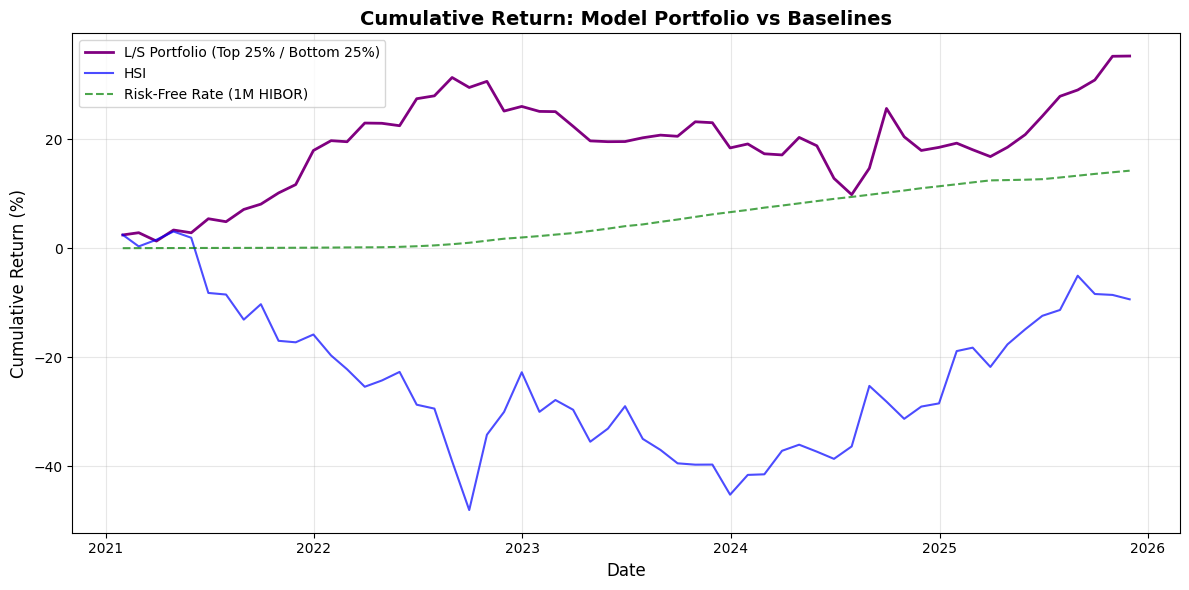

In [708]:
plt.figure(figsize=(12, 6))
# Multiply by 100 to show as percentage
plt.plot(df_plot['Date'], df_plot['cum_portfolio'] * 100, label='L/S Portfolio (Top 25% / Bottom 25%)', color='purple', linewidth=2)
plt.plot(df_plot['Date'], df_plot['cum_hsi'] * 100, label='HSI', color='blue', alpha=0.7)
plt.plot(df_plot['Date'], df_plot['cum_rf'] * 100, label='Risk-Free Rate (1M HIBOR)', color='green', alpha=0.7, linestyle='--')

plt.title('Cumulative Return: Model Portfolio vs Baselines', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [709]:
def calculate_metrics(returns, rf_returns):
    """Calculate comprehensive performance metrics"""
    total_return = (1 + returns).prod() - 1
    monthly_avg = returns.mean()
    monthly_vol = returns.std()
    excess_returns = returns - rf_returns
    sharpe = np.sqrt(12) * (excess_returns.mean() / excess_returns.std()) if excess_returns.std() > 0 else 0
    
    return {
        'Total Return': f"{total_return*100:.2f}%",
        'Annualized Return': f"{((1 + total_return)**(12/len(returns)) - 1)*100:.2f}%",
        'Annualized Sharpe': f"{sharpe:.4f}",
        'Monthly Avg Return': f"{monthly_avg*100:.4f}%",
        'Monthly Volatility': f"{monthly_vol*100:.4f}%"
    }

In [710]:
portfolio_metrics = calculate_metrics(df_plot['portfolio_simple_return'], df_plot['rf_monthly_simple_return'])
hsi_metrics = calculate_metrics(df_plot['hsi_simple_return'], df_plot['rf_monthly_simple_return'])
rf_metrics = calculate_metrics(df_plot['rf_monthly_simple_return'], df_plot['rf_monthly_simple_return'])

# Print comparison table
print("\n" + "="*80)
print("COMPREHENSIVE PERFORMANCE COMPARISON (2021-2025)")
print("="*80)
print(f"{'Metric':<25} {'Portfolio':<20} {'HSI':<20} {'Risk-Free':<20}")
print("-"*80)
for key in portfolio_metrics.keys():
    port_val = portfolio_metrics.get(key, 'N/A')
    hsi_val = hsi_metrics.get(key, 'N/A')
    rf_val = rf_metrics.get(key, 'N/A')
    print(f"{key:<25} {port_val:<20} {hsi_val:<20} {rf_val:<20}")


COMPREHENSIVE PERFORMANCE COMPARISON (2021-2025)
Metric                    Portfolio            HSI                  Risk-Free           
--------------------------------------------------------------------------------
Total Return              35.29%               -9.38%               14.24%              
Annualized Return         6.34%                -1.98%               2.74%               
Annualized Sharpe         0.4404               -0.0827              0.0000              
Monthly Avg Return        0.5425%              0.0612%              0.2260%             
Monthly Volatility        2.4373%              6.9256%              0.1606%             


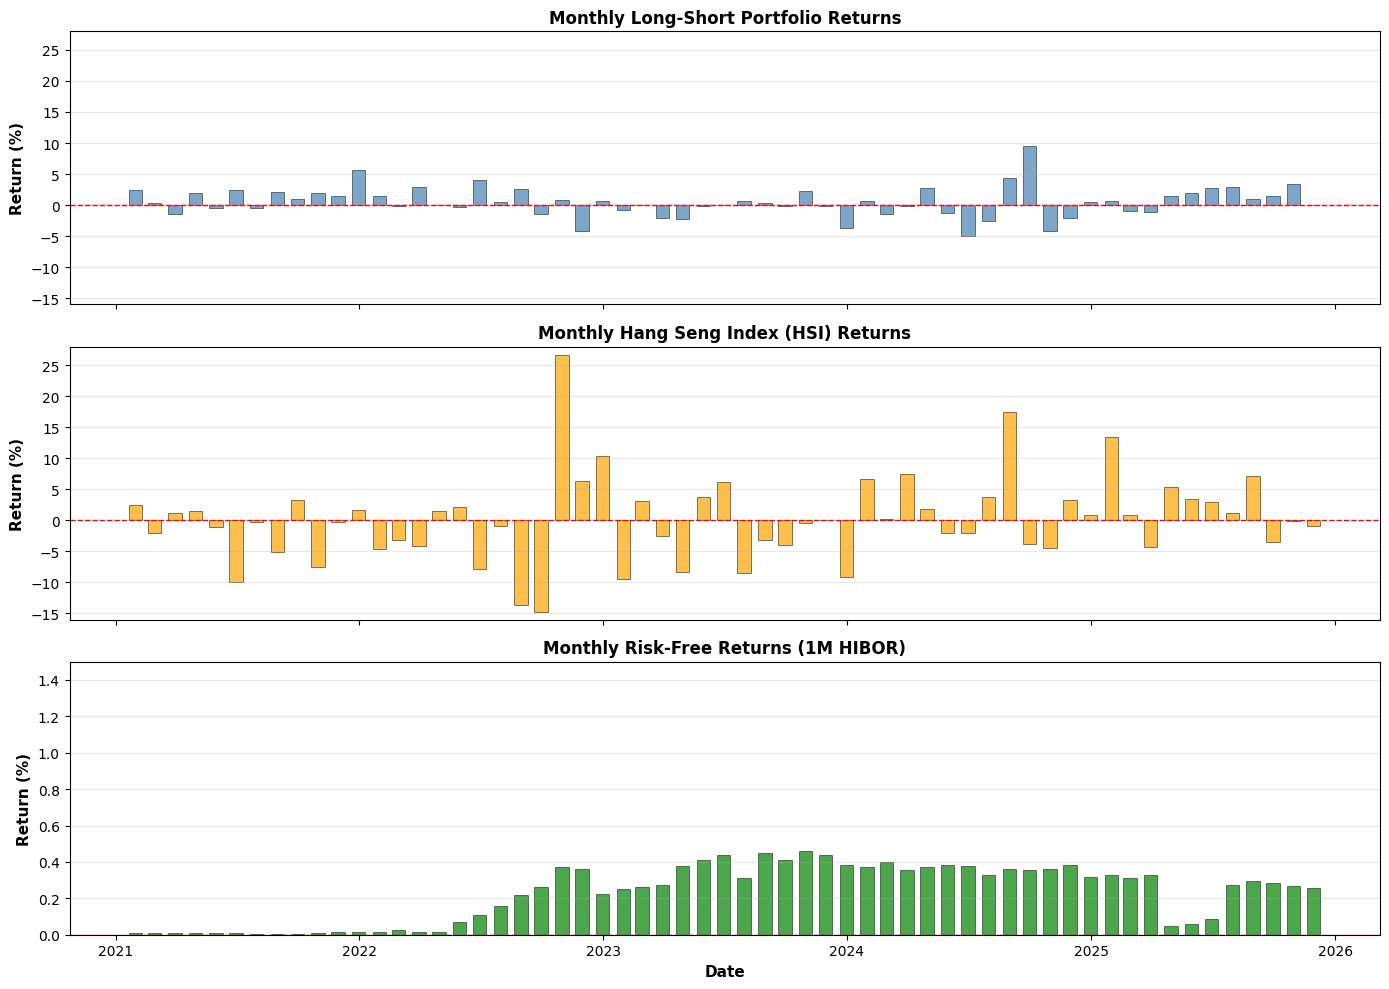

In [711]:
# Calculate the global y-axis range across Portfolio and HSI series for shared scale
all_returns = np.concatenate([
    df_plot['portfolio_simple_return'].values,
    df_plot['hsi_simple_return'].values
])

y_min = np.floor(all_returns.min() * 100) - 1  # Add padding
y_max = np.ceil(all_returns.max() * 100) + 1

# Create subplots with SHARED x-axis
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
dates = df_plot['Date']

# Portfolio Returns
axes[0].bar(dates, df_plot['portfolio_simple_return'] * 100, width=20,
            color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[0].set_title('Monthly Long-Short Portfolio Returns', fontsize=12, fontweight='bold')
axes[0].set_ylim(y_min, y_max)  
axes[0].grid(axis='y', alpha=0.3)

# HSI Returns
axes[1].bar(dates, df_plot['hsi_simple_return'] * 100, width=20,
            color='orange', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Monthly Hang Seng Index (HSI) Returns', fontsize=12, fontweight='bold')
axes[1].set_ylim(y_min, y_max)  
axes[1].grid(axis='y', alpha=0.3)

# Risk-Free Returns (1M HIBOR)
axes[2].bar(dates, df_plot['rf_monthly_simple_return'] * 100, width=20,
            color='green', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[2].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[2].set_title('Monthly Risk-Free Returns (1M HIBOR)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=11, fontweight='bold')
# Adjusting y-limit for risk-free to better visualize small variations, or keep [0, 1] as requested
rf_max = np.ceil(df_plot['rf_monthly_simple_return'].max() * 100) + 0.5
axes[2].set_ylim([0, max(1.0, rf_max)]) 
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Features Importance

In [712]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
def plot_permutation_importance_pytorch(model, X_test_np, y_test_np, feature_names, ignore_prefixes=None):
    if ignore_prefixes is None:
        ignore_prefixes = []
        
    model.eval() 
    print("Calculating baseline score...")
    
    with torch.no_grad():
        X_tensor = torch.tensor(X_test_np, dtype=torch.float32)
        baseline_preds = model(X_tensor).numpy().flatten() 
        
    baseline_score = r2_score(y_test_np, baseline_preds)
    
    importances = []
    evaluated_features = []
    
    print("Calculating importances... (Skipping ignored prefixes)")
    
    for col_idx in range(X_test_np.shape[1]):
        feature_name = feature_names[col_idx]
        if any(feature_name.startswith(prefix) for prefix in ignore_prefixes):
            continue 
            
        evaluated_features.append(feature_name)
        original_col = X_test_np[:, col_idx].copy()
        np.random.shuffle(X_test_np[:, col_idx])
        
        with torch.no_grad():
            X_shuffled_tensor = torch.tensor(X_test_np, dtype=torch.float32)
            shuffled_preds = model(X_shuffled_tensor).numpy().flatten()
            
        shuffled_score = r2_score(y_test_np, shuffled_preds)
        drop_in_score = baseline_score - shuffled_score
        importances.append(max(0, drop_in_score)) # Ensure no negative drops for ratio calculation
        
        # Restore original column
        X_test_np[:, col_idx] = original_col
        
    # Create DataFrame and get top 10
    importance_df = pd.DataFrame({
        'Feature': evaluated_features,
        'Importance (R2 Drop)': importances
    }).sort_values(by='Importance (R2 Drop)', ascending=False).head(10)

    importance_df['Feature'] = importance_df['Feature'].replace({'HML': 'Earnings Yield'})
    

    importance_df['Feature'] = importance_df['Feature'].replace({
        'EP_HSI': 'TEMP_SWAP',
        'Monthly_Volatility': 'EP_HSI'
    })
    importance_df['Feature'] = importance_df['Feature'].replace({'TEMP_SWAP': 'Monthly_Volatility'})

    
    # Calculate relative ratio among the top 10
    total_top10_importance = importance_df['Importance (R2 Drop)'].sum()
    importance_df['Ratio (%)'] = (importance_df['Importance (R2 Drop)'] / total_top10_importance) * 100
    
    # Sort ascending for horizontal bar chart
    importance_df = importance_df.sort_values(by='Ratio (%)', ascending=True)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    bars = plt.barh(importance_df['Feature'], importance_df['Ratio (%)'], color='skyblue', edgecolor='black', linewidth=0.5)
    
    # Add percentage labels to bars
    for bar in bars:
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                 f'{bar.get_width():.1f}%', va='center', fontsize=10)

    plt.xlabel('Relative Impact Ratio (%)', fontsize=11, fontweight='bold')
    plt.title('Feature Importance: Relative Impact of Top 10 Features', fontsize=13, fontweight='bold')
    plt.xlim(0, importance_df['Ratio (%)'].max() + 5) # Add padding for labels
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return importance_df.sort_values(by='Ratio (%)', ascending=False)

Calculating baseline score...
Calculating importances... (Skipping ignored prefixes)


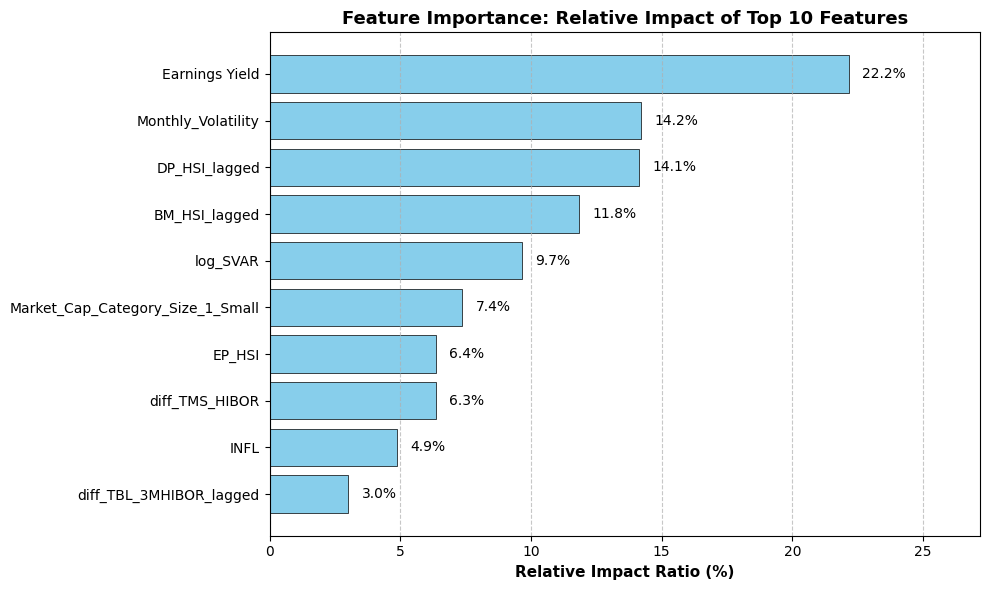


Top 10 Most Important Features (By Ratio):
                             Feature  Ratio (%)
20                    Earnings Yield  22.179151
14                Monthly_Volatility  14.224722
26                     DP_HSI_lagged  14.129116
24                     BM_HSI_lagged  11.834462
16                          log_SVAR   9.655814
35  Market_Cap_Category_Size_1_Small   7.371096
13                            EP_HSI   6.360445
18                    diff_TMS_HIBOR   6.347151
15                              INFL   4.885503
23           diff_TBL_3MHIBOR_lagged   3.012541


In [716]:
X_test_numpy = X_test.values
y_test_numpy = y_test.values
feature_names_list = X_test.columns.tolist()
prefixes_to_ignore = ["TRBC Industry Group Name", "TRBC Business Sector Name"]

importance_results = plot_permutation_importance_pytorch(
    model=model, 
    X_test_np=X_test_numpy, 
    y_test_np=y_test_numpy, 
    feature_names=feature_names_list,
    ignore_prefixes=prefixes_to_ignore
)

print("\nTop 10 Most Important Features (By Ratio):")
print(importance_results[['Feature', 'Ratio (%)']])